In [1]:
# %% ライブラリ
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from scipy.stats import ks_2samp, chi2_contingency
from sklearn.metrics import accuracy_score
from sklearn.kernel_ridge import KernelRidge
import os


In [2]:
input_dir = os.path.join("in", "PWSCUP2025_Main_Data_for_Attack")
files = sorted(f for f in os.listdir(input_dir) if f.startswith("AA") and f.endswith(".csv"))
result = [os.path.join(input_dir, file) for file in files]
if not result:
    raise FileNotFoundError("No CSV files starting with 'A' were found in in/PWSCUP2025_Main_Data_for_Attack.")



In [3]:
result

['in\\PWSCUP2025_Main_Data_for_Attack\\AA01.csv',
 'in\\PWSCUP2025_Main_Data_for_Attack\\AA02.csv',
 'in\\PWSCUP2025_Main_Data_for_Attack\\AA03.csv',
 'in\\PWSCUP2025_Main_Data_for_Attack\\AA04.csv',
 'in\\PWSCUP2025_Main_Data_for_Attack\\AA05.csv',
 'in\\PWSCUP2025_Main_Data_for_Attack\\AA06.csv',
 'in\\PWSCUP2025_Main_Data_for_Attack\\AA07.csv',
 'in\\PWSCUP2025_Main_Data_for_Attack\\AA08.csv',
 'in\\PWSCUP2025_Main_Data_for_Attack\\AA09.csv',
 'in\\PWSCUP2025_Main_Data_for_Attack\\AA10.csv',
 'in\\PWSCUP2025_Main_Data_for_Attack\\AA11.csv',
 'in\\PWSCUP2025_Main_Data_for_Attack\\AA12.csv',
 'in\\PWSCUP2025_Main_Data_for_Attack\\AA13.csv',
 'in\\PWSCUP2025_Main_Data_for_Attack\\AA14.csv',
 'in\\PWSCUP2025_Main_Data_for_Attack\\AA15.csv',
 'in\\PWSCUP2025_Main_Data_for_Attack\\AA16.csv',
 'in\\PWSCUP2025_Main_Data_for_Attack\\AA17.csv',
 'in\\PWSCUP2025_Main_Data_for_Attack\\AA18.csv',
 'in\\PWSCUP2025_Main_Data_for_Attack\\AA19.csv',
 'in\\PWSCUP2025_Main_Data_for_Attack\\AA20.csv',


In [4]:
MAX_SAMPLE_PER_DATASET = 5000

datasets = []
dataset_names = []

for fp in result:
    df = pd.read_csv(fp)
    if MAX_SAMPLE_PER_DATASET is not None and len(df) > MAX_SAMPLE_PER_DATASET:
        df = df.sample(n=MAX_SAMPLE_PER_DATASET, random_state=42)
    datasets.append(df.reset_index(drop=True))
    dataset_names.append(os.path.splitext(os.path.basename(fp))[0])

if not datasets:
    raise ValueError("No datasets were loaded. Confirm that the file list is correct.")



=== AA01: 基本統計量 ===
       GENDER         AGE   RACE    ETHNICITY  encounter_count  \
count    5000  5000.00000   5000         5000      5000.000000   
unique      2         NaN      6            2              NaN   
top         M         NaN  white  nonhispanic              NaN   
freq     2639         NaN   4391         3878              NaN   
mean      NaN    46.55280    NaN          NaN        61.691200   
std       NaN    25.57814    NaN          NaN        94.180762   
min       NaN     2.00000    NaN          NaN         8.000000   
25%       NaN    23.00000    NaN          NaN        25.000000   
50%       NaN    49.00000    NaN          NaN        36.000000   
75%       NaN    64.00000    NaN          NaN        58.000000   
max       NaN   110.00000    NaN          NaN       874.000000   

        num_procedures  num_medications  num_immunizations  num_allergies  \
count      5000.000000      5000.000000        5000.000000    5000.000000   
unique             NaN          

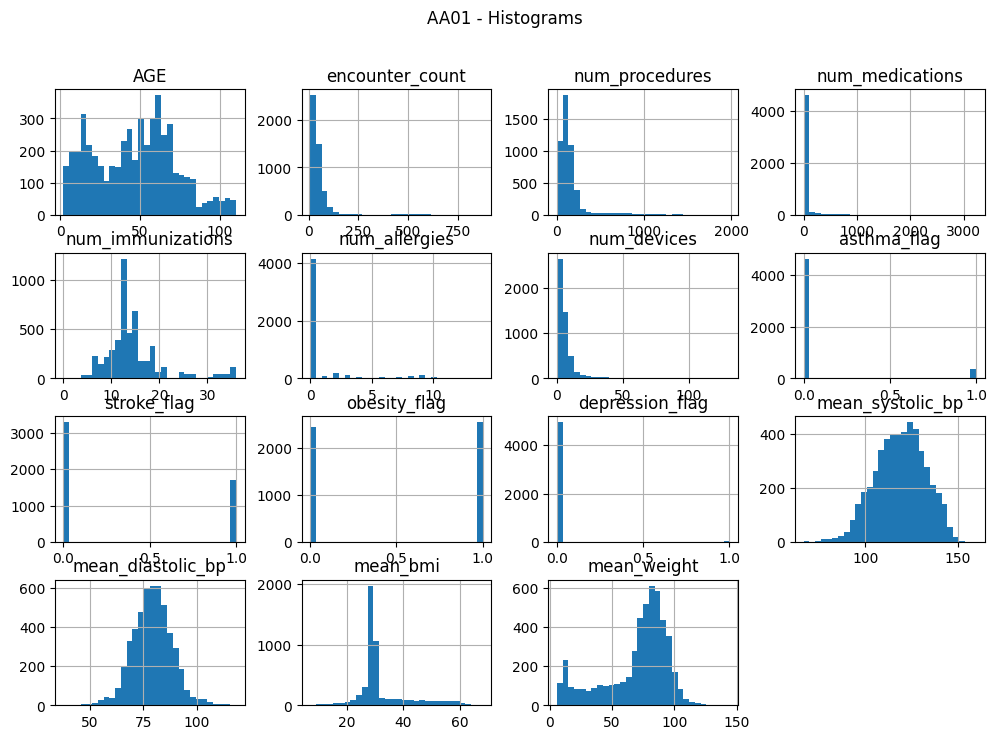


=== AA02: 基本統計量 ===
       GENDER          AGE   RACE    ETHNICITY  encounter_count  \
count    5000  5000.000000   5000         5000      5000.000000   
unique      2          NaN      6            2              NaN   
top         M          NaN  white  nonhispanic              NaN   
freq     2578          NaN   3688         4895              NaN   
mean      NaN    45.936400    NaN          NaN        63.417600   
std       NaN    27.067325    NaN          NaN        96.436578   
min       NaN     2.000000    NaN          NaN         7.000000   
25%       NaN    22.000000    NaN          NaN        25.000000   
50%       NaN    47.000000    NaN          NaN        37.000000   
75%       NaN    66.000000    NaN          NaN        61.000000   
max       NaN   110.000000    NaN          NaN       862.000000   

        num_procedures  num_medications  num_immunizations  num_allergies  \
count      5000.000000      5000.000000        5000.000000    5000.000000   
unique             N

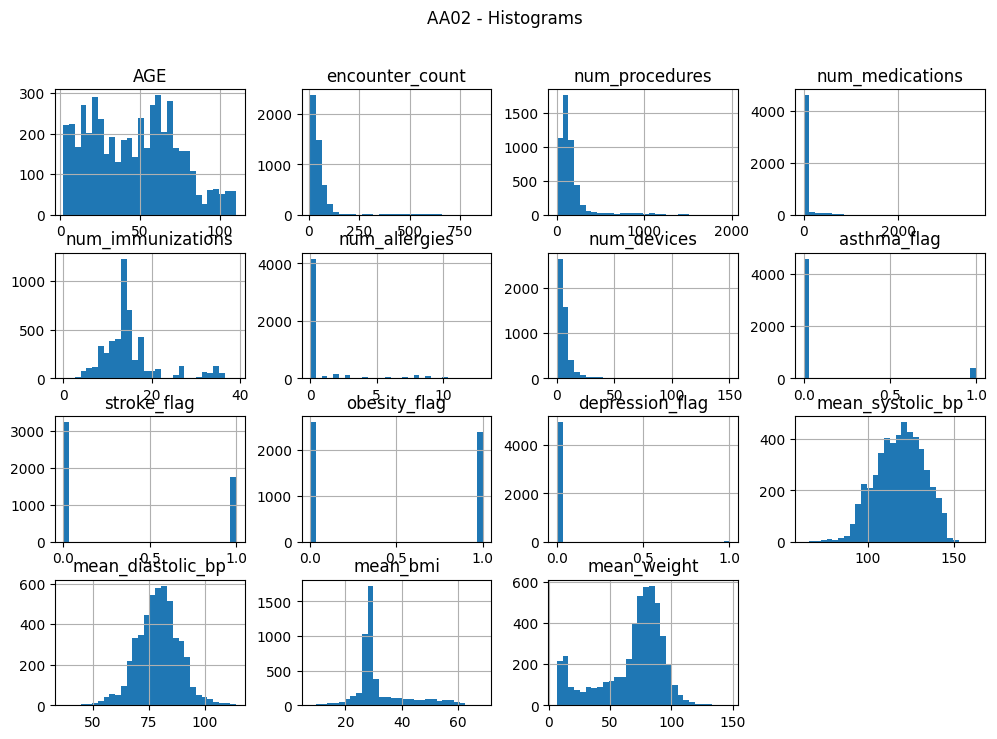


=== AA03: 基本統計量 ===
       GENDER          AGE   RACE    ETHNICITY  encounter_count  \
count    5000  5000.000000   5000         5000       5000.00000   
unique      2          NaN      6            2              NaN   
top         M          NaN  white  nonhispanic              NaN   
freq     2676          NaN   4761         4899              NaN   
mean      NaN    47.642000    NaN          NaN         63.38060   
std       NaN    25.719598    NaN          NaN         95.64737   
min       NaN     2.000000    NaN          NaN          8.00000   
25%       NaN    26.000000    NaN          NaN         25.00000   
50%       NaN    50.000000    NaN          NaN         37.00000   
75%       NaN    65.000000    NaN          NaN         60.00000   
max       NaN   110.000000    NaN          NaN        888.00000   

        num_procedures  num_medications  num_immunizations  num_allergies  \
count      5000.000000      5000.000000        5000.000000    5000.000000   
unique             N

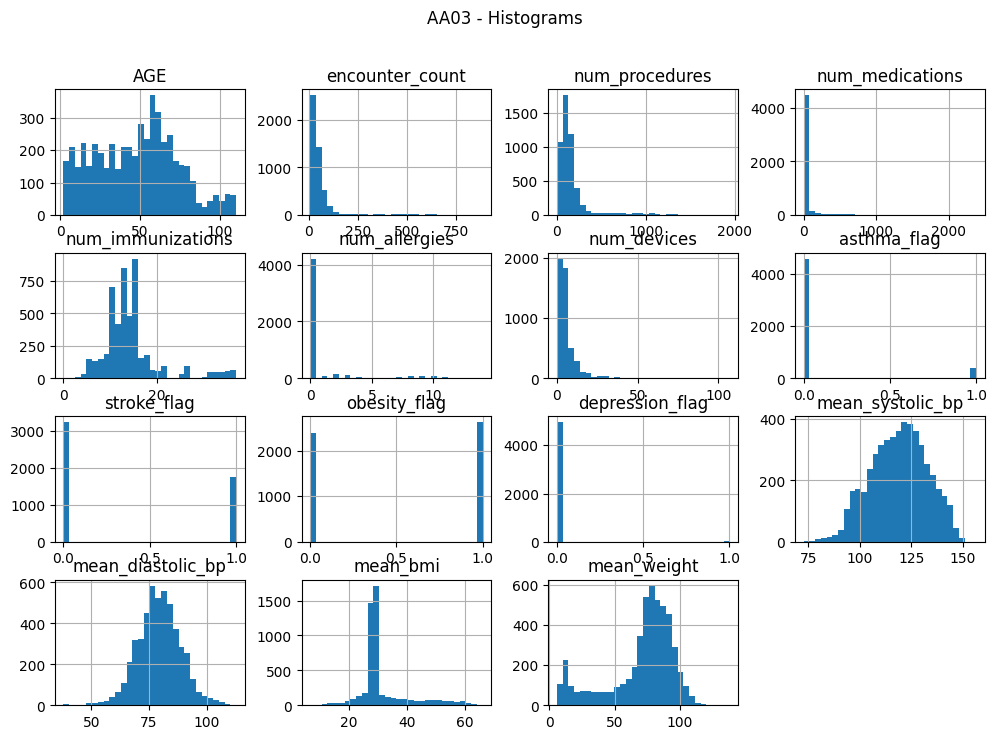


=== AA04: 基本統計量 ===
       GENDER          AGE   RACE    ETHNICITY  encounter_count  \
count    5000  5000.000000   5000         5000      5000.000000   
unique      2          NaN      6            2              NaN   
top         M          NaN  white  nonhispanic              NaN   
freq     2574          NaN   4436         4742              NaN   
mean      NaN    56.143000    NaN          NaN        75.604800   
std       NaN    26.934573    NaN          NaN       113.297113   
min       NaN     2.000000    NaN          NaN         9.000000   
25%       NaN    38.000000    NaN          NaN        29.000000   
50%       NaN    62.000000    NaN          NaN        42.000000   
75%       NaN    74.000000    NaN          NaN        67.000000   
max       NaN   110.000000    NaN          NaN       814.000000   

        num_procedures  num_medications  num_immunizations  num_allergies  \
count      5000.000000      5000.000000        5000.000000    5000.000000   
unique             N

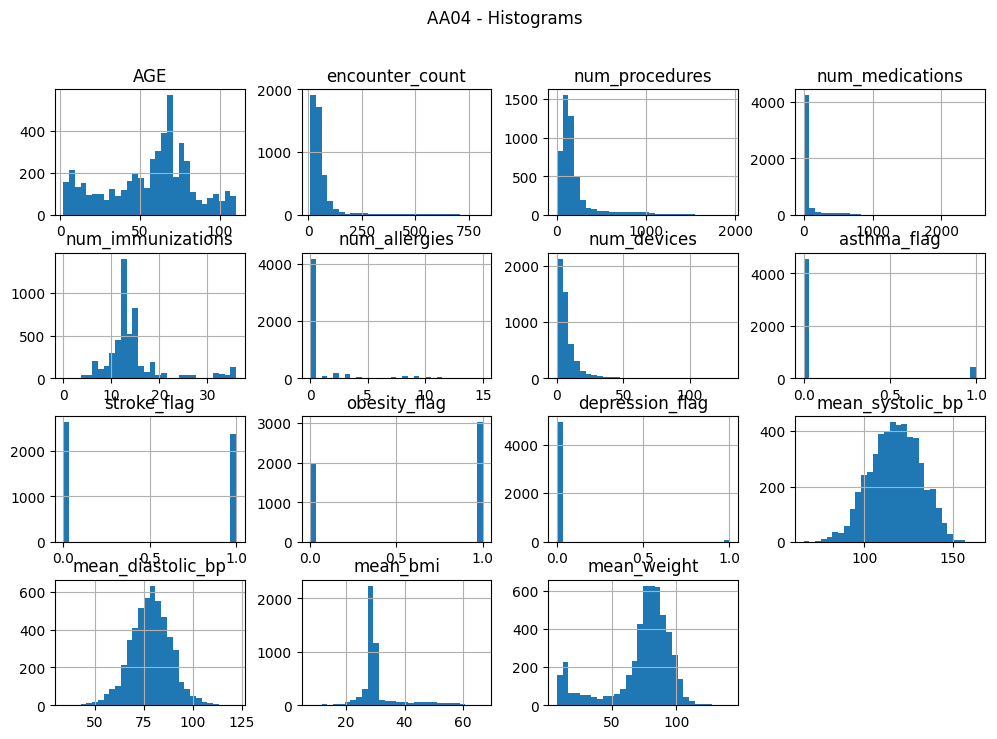


=== AA05: 基本統計量 ===
       GENDER          AGE   RACE    ETHNICITY  encounter_count  \
count    5000  5000.000000   5000         5000      5000.000000   
unique      2          NaN      6            2              NaN   
top         M          NaN  white  nonhispanic              NaN   
freq     2573          NaN   4822         4919              NaN   
mean      NaN    47.036600    NaN          NaN        63.372000   
std       NaN    25.913154    NaN          NaN        95.230652   
min       NaN     2.000000    NaN          NaN         8.000000   
25%       NaN    25.000000    NaN          NaN        25.000000   
50%       NaN    49.000000    NaN          NaN        37.000000   
75%       NaN    65.000000    NaN          NaN        61.000000   
max       NaN   110.000000    NaN          NaN       797.000000   

        num_procedures  num_medications  num_immunizations  num_allergies  \
count      5000.000000      5000.000000        5000.000000    5000.000000   
unique             N

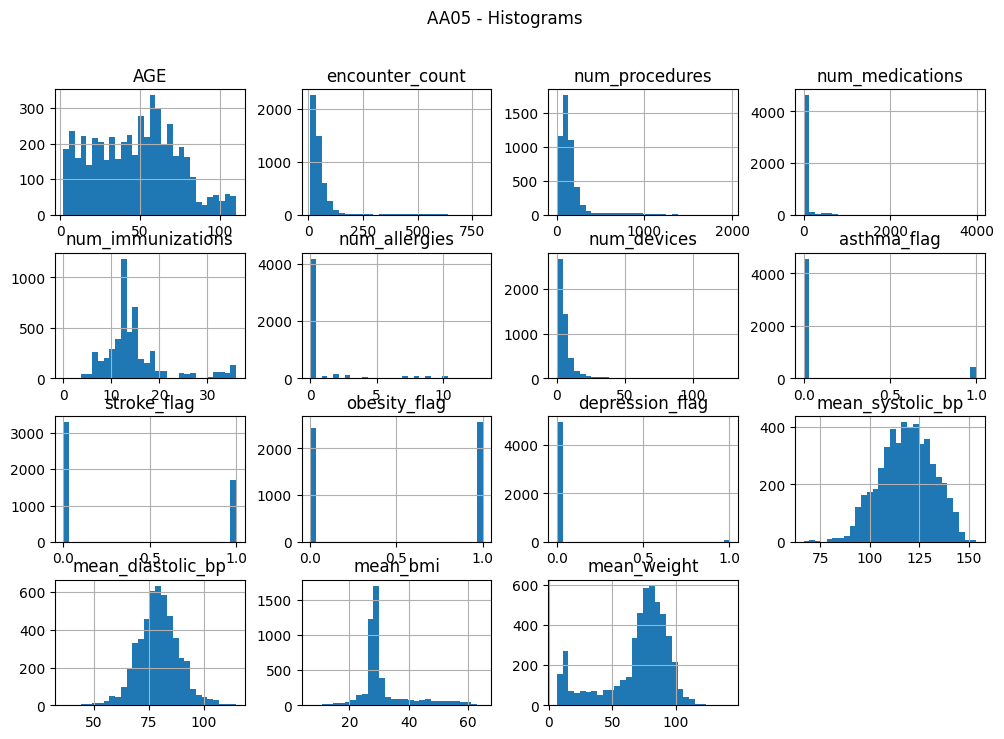


=== AA06: 基本統計量 ===
       GENDER          AGE   RACE    ETHNICITY  encounter_count  \
count    5000  5000.000000   5000         5000      5000.000000   
unique      2          NaN      6            2              NaN   
top         M          NaN  white  nonhispanic              NaN   
freq     2545          NaN   3970         4767              NaN   
mean      NaN    43.540400    NaN          NaN        59.956800   
std       NaN    25.866035    NaN          NaN        94.175241   
min       NaN     2.000000    NaN          NaN         6.000000   
25%       NaN    22.000000    NaN          NaN        24.000000   
50%       NaN    42.000000    NaN          NaN        35.000000   
75%       NaN    62.000000    NaN          NaN        56.000000   
max       NaN   110.000000    NaN          NaN       921.000000   

        num_procedures  num_medications  num_immunizations  num_allergies  \
count       5000.00000      5000.000000        5000.000000    5000.000000   
unique             N

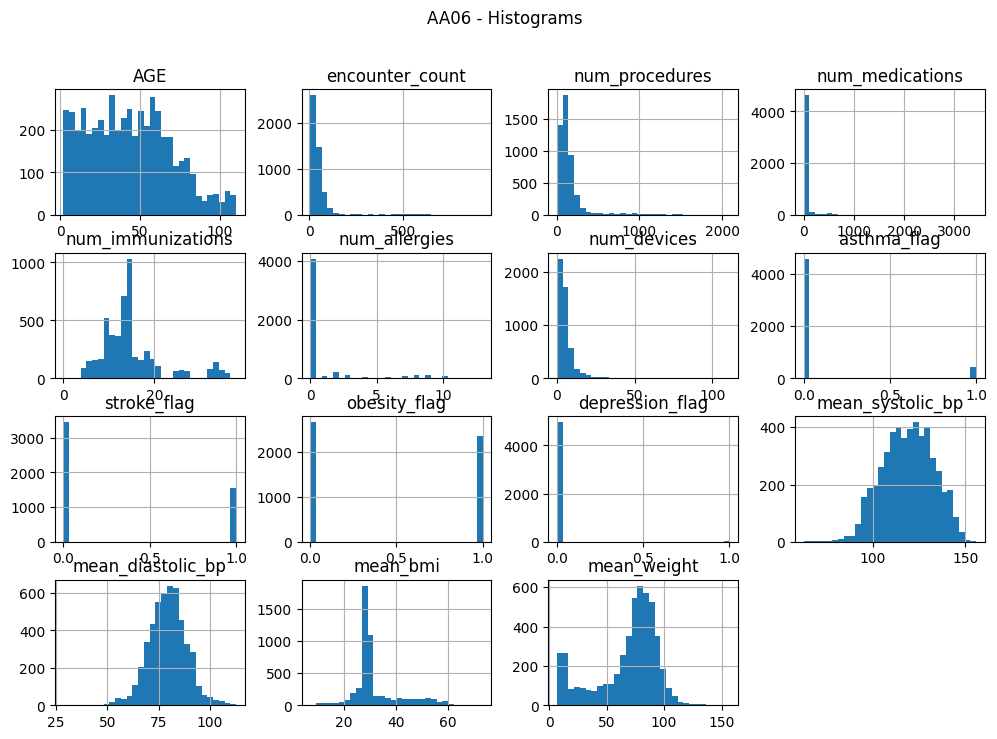


=== AA07: 基本統計量 ===
       GENDER         AGE   RACE    ETHNICITY  encounter_count  \
count    5000  5000.00000   5000         5000      5000.000000   
unique      2         NaN      6            2              NaN   
top         M         NaN  white  nonhispanic              NaN   
freq     2594         NaN   4417         4664              NaN   
mean      NaN    48.76520    NaN          NaN        67.135600   
std       NaN    25.17239    NaN          NaN        98.673535   
min       NaN     2.00000    NaN          NaN         8.000000   
25%       NaN    29.00000    NaN          NaN        26.000000   
50%       NaN    51.00000    NaN          NaN        40.000000   
75%       NaN    66.00000    NaN          NaN        66.000000   
max       NaN   110.00000    NaN          NaN       829.000000   

        num_procedures  num_medications  num_immunizations  num_allergies  \
count      5000.000000      5000.000000        5000.000000    5000.000000   
unique             NaN          

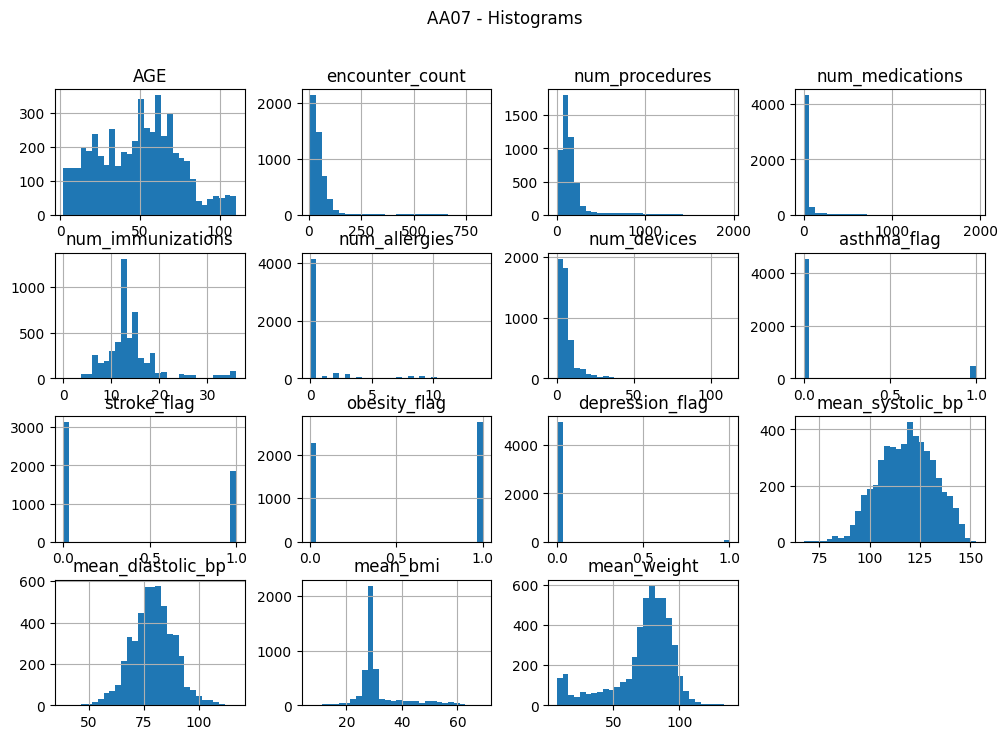


=== AA08: 基本統計量 ===
       GENDER          AGE   RACE    ETHNICITY  encounter_count  \
count    5000  5000.000000   5000         5000      5000.000000   
unique      2          NaN      6            2              NaN   
top         M          NaN  white  nonhispanic              NaN   
freq     2555          NaN   4498         4819              NaN   
mean      NaN    47.720200    NaN          NaN        65.923800   
std       NaN    26.154157    NaN          NaN        94.213239   
min       NaN     2.000000    NaN          NaN         8.000000   
25%       NaN    26.000000    NaN          NaN        26.000000   
50%       NaN    49.000000    NaN          NaN        40.000000   
75%       NaN    67.000000    NaN          NaN        67.000000   
max       NaN   110.000000    NaN          NaN       840.000000   

        num_procedures  num_medications  num_immunizations  num_allergies  \
count      5000.000000      5000.000000        5000.000000    5000.000000   
unique             N

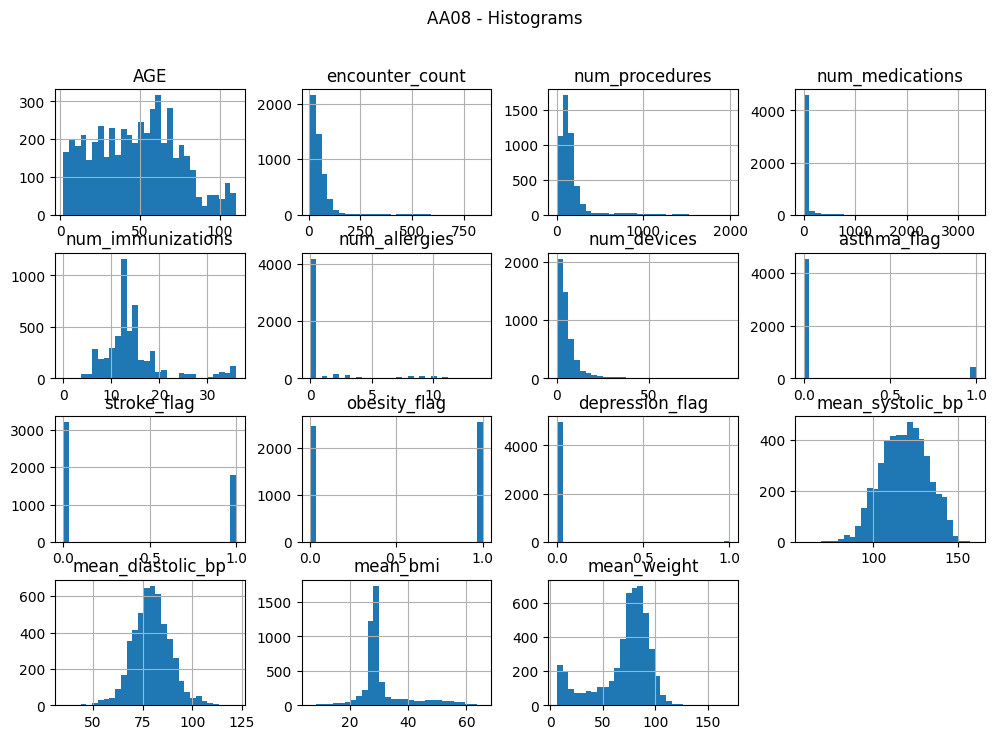


=== AA09: 基本統計量 ===
       GENDER          AGE   RACE    ETHNICITY  encounter_count  \
count    5000  5000.000000   5000         5000      5000.000000   
unique      2          NaN      6            2              NaN   
top         F          NaN  white  nonhispanic              NaN   
freq     2500          NaN   4459         4886              NaN   
mean      NaN    47.604000    NaN          NaN        62.860000   
std       NaN    25.558557    NaN          NaN        95.579451   
min       NaN     2.000000    NaN          NaN         7.000000   
25%       NaN    26.000000    NaN          NaN        26.000000   
50%       NaN    50.000000    NaN          NaN        37.000000   
75%       NaN    65.000000    NaN          NaN        58.000000   
max       NaN   110.000000    NaN          NaN       819.000000   

        num_procedures  num_medications  num_immunizations  num_allergies  \
count      5000.000000      5000.000000        5000.000000    5000.000000   
unique             N

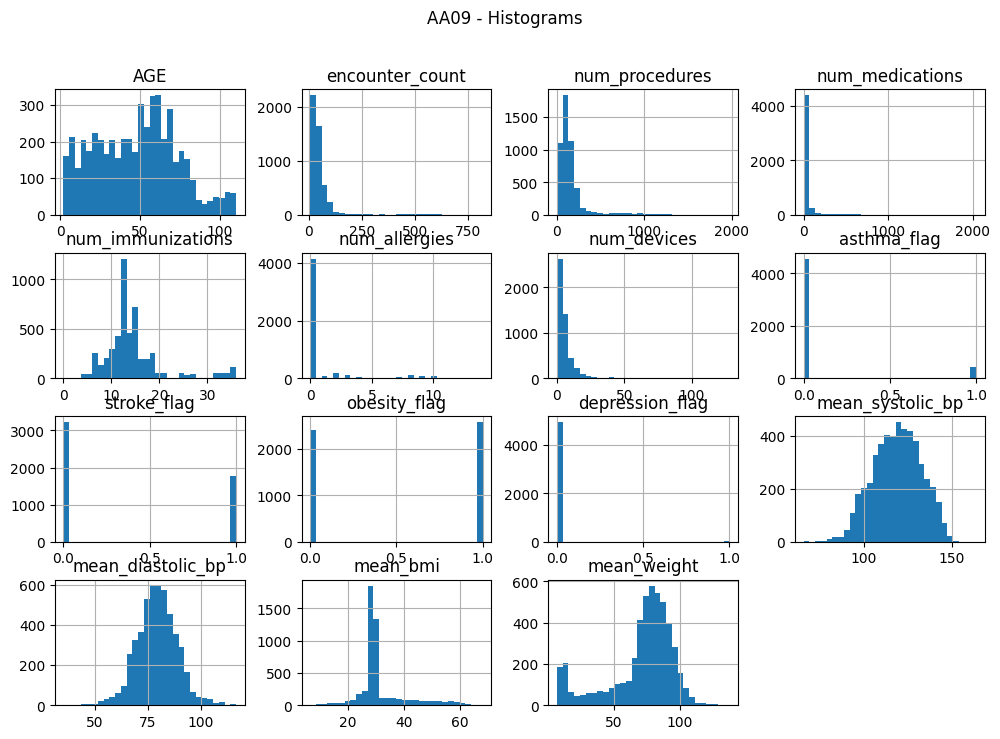


=== AA10: 基本統計量 ===
       GENDER          AGE   RACE    ETHNICITY  encounter_count  \
count    5000  5000.000000   5000         5000      5000.000000   
unique      2          NaN      6            2              NaN   
top         M          NaN  white  nonhispanic              NaN   
freq     2505          NaN   4664         4913              NaN   
mean      NaN    46.006200    NaN          NaN        61.439000   
std       NaN    26.034987    NaN          NaN        87.557729   
min       NaN     2.000000    NaN          NaN         7.000000   
25%       NaN    23.000000    NaN          NaN        25.000000   
50%       NaN    46.000000    NaN          NaN        38.000000   
75%       NaN    64.250000    NaN          NaN        62.000000   
max       NaN   110.000000    NaN          NaN       778.000000   

        num_procedures  num_medications  num_immunizations  num_allergies  \
count      5000.000000      5000.000000        5000.000000    5000.000000   
unique             N

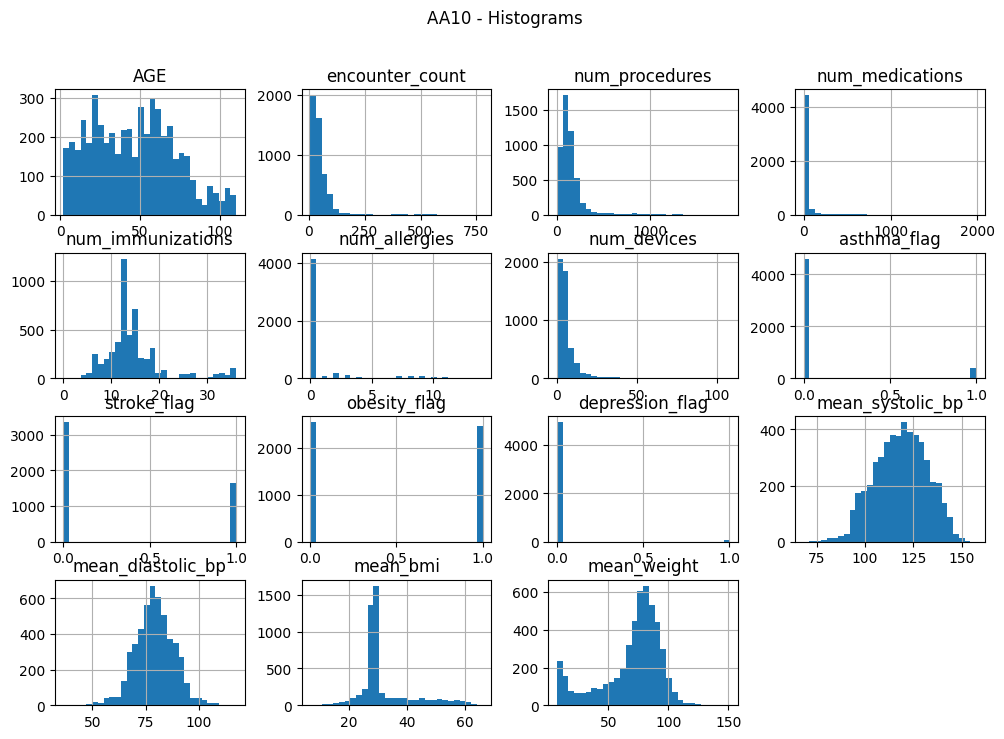


=== AA11: 基本統計量 ===
       GENDER          AGE   RACE    ETHNICITY  encounter_count  \
count    5000  5000.000000   5000         5000      5000.000000   
unique      2          NaN      6            2              NaN   
top         M          NaN  white  nonhispanic              NaN   
freq     2607          NaN   4627         4704              NaN   
mean      NaN    47.990400    NaN          NaN        63.270800   
std       NaN    25.974612    NaN          NaN        91.886837   
min       NaN     2.000000    NaN          NaN         8.000000   
25%       NaN    25.000000    NaN          NaN        26.000000   
50%       NaN    50.000000    NaN          NaN        38.000000   
75%       NaN    67.000000    NaN          NaN        62.000000   
max       NaN   110.000000    NaN          NaN       807.000000   

        num_procedures  num_medications  num_immunizations  num_allergies  \
count       5000.00000      5000.000000        5000.000000    5000.000000   
unique             N

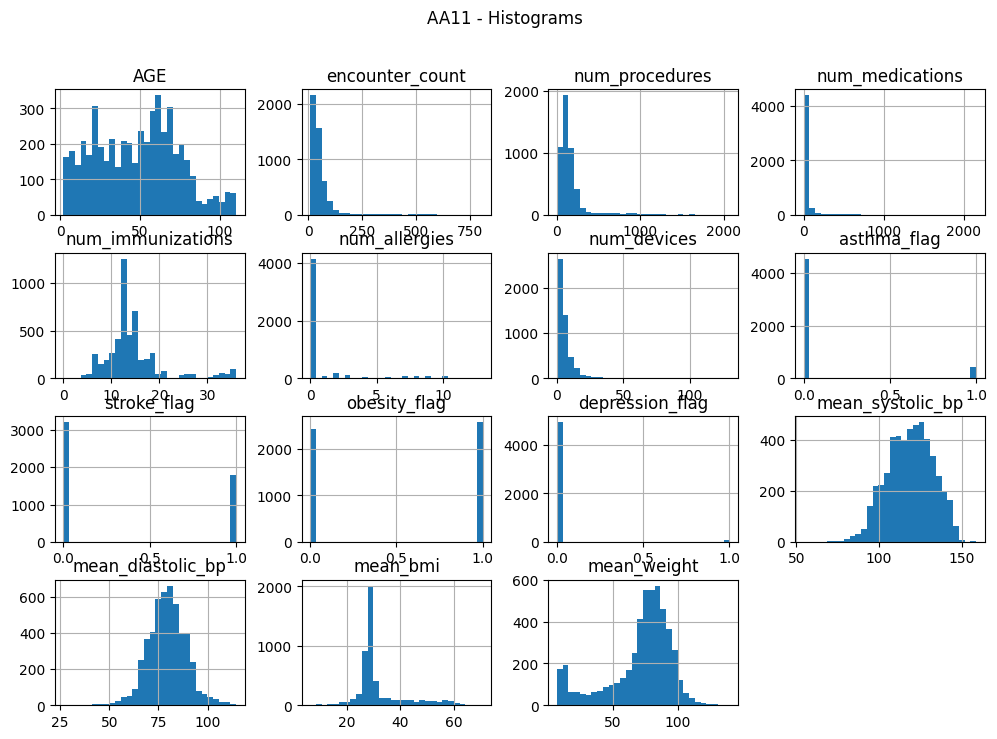


=== AA12: 基本統計量 ===
       GENDER          AGE   RACE    ETHNICITY  encounter_count  \
count    5000  5000.000000   5000         5000      5000.000000   
unique      2          NaN      6            2              NaN   
top         M          NaN  white  nonhispanic              NaN   
freq     2563          NaN   4575         4555              NaN   
mean      NaN    45.999000    NaN          NaN        62.186000   
std       NaN    25.018669    NaN          NaN        97.994949   
min       NaN     2.000000    NaN          NaN         7.000000   
25%       NaN    25.000000    NaN          NaN        25.000000   
50%       NaN    46.000000    NaN          NaN        37.000000   
75%       NaN    64.000000    NaN          NaN        58.000000   
max       NaN   110.000000    NaN          NaN       818.000000   

        num_procedures  num_medications  num_immunizations  num_allergies  \
count      5000.000000      5000.000000        5000.000000    5000.000000   
unique             N

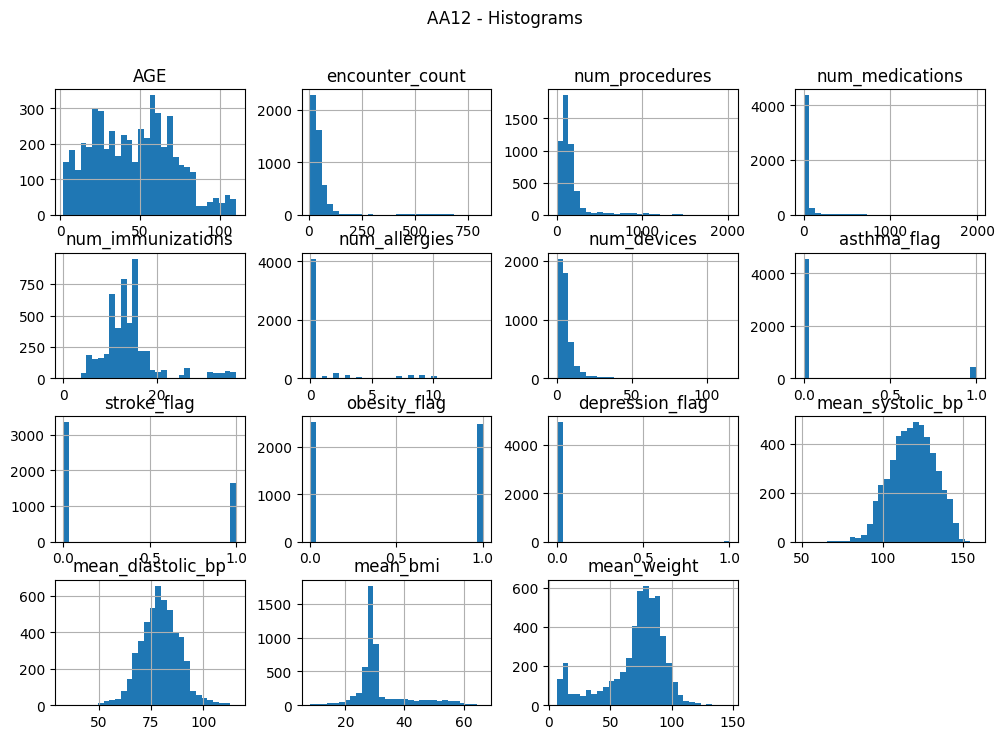


=== AA13: 基本統計量 ===
       GENDER          AGE   RACE    ETHNICITY  encounter_count  \
count    5000  5000.000000   5000         5000      5000.000000   
unique      2          NaN      6            2              NaN   
top         F          NaN  white  nonhispanic              NaN   
freq     2514          NaN   4183         4859              NaN   
mean      NaN    44.553000    NaN          NaN        60.269400   
std       NaN    25.470386    NaN          NaN        88.834846   
min       NaN     2.000000    NaN          NaN         7.000000   
25%       NaN    23.000000    NaN          NaN        25.000000   
50%       NaN    44.000000    NaN          NaN        37.000000   
75%       NaN    63.000000    NaN          NaN        59.000000   
max       NaN   110.000000    NaN          NaN       897.000000   

        num_procedures  num_medications  num_immunizations  num_allergies  \
count      5000.000000      5000.000000        5000.000000    5000.000000   
unique             N

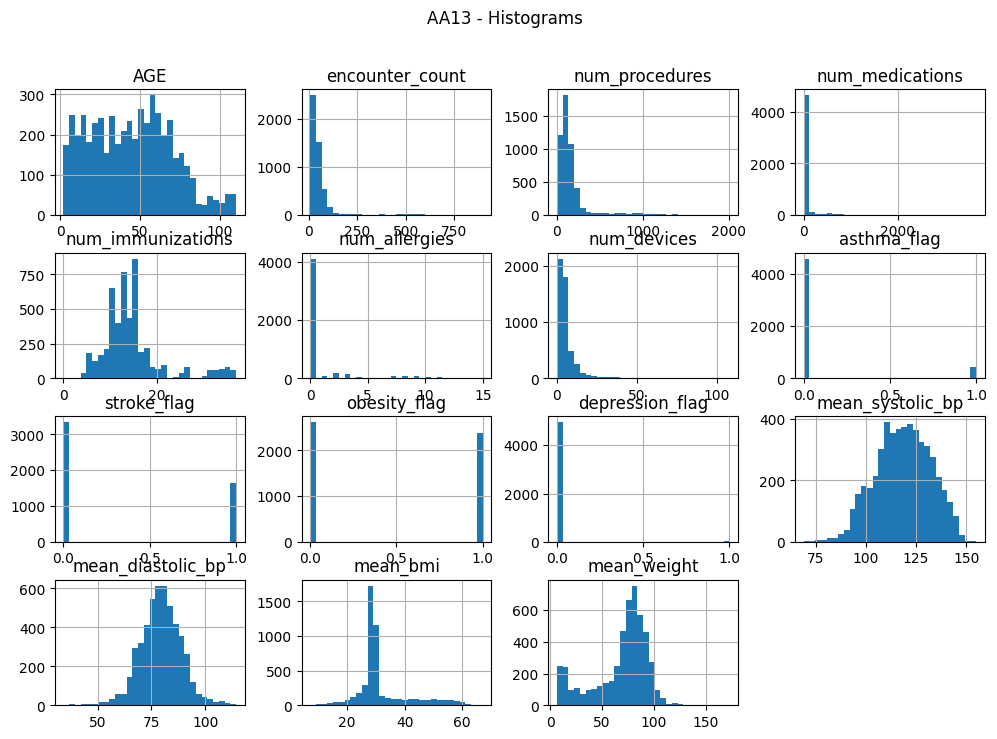


=== AA14: 基本統計量 ===
       GENDER          AGE   RACE    ETHNICITY  encounter_count  \
count    5000  5000.000000   5000         5000      5000.000000   
unique      2          NaN      6            2              NaN   
top         M          NaN  white  nonhispanic              NaN   
freq     2603          NaN   4179         4874              NaN   
mean      NaN    49.615800    NaN          NaN        68.699000   
std       NaN    26.009058    NaN          NaN       103.410048   
min       NaN     2.000000    NaN          NaN         7.000000   
25%       NaN    28.000000    NaN          NaN        26.000000   
50%       NaN    52.000000    NaN          NaN        40.000000   
75%       NaN    69.000000    NaN          NaN        66.000000   
max       NaN   110.000000    NaN          NaN       881.000000   

        num_procedures  num_medications  num_immunizations  num_allergies  \
count      5000.000000      5000.000000        5000.000000    5000.000000   
unique             N

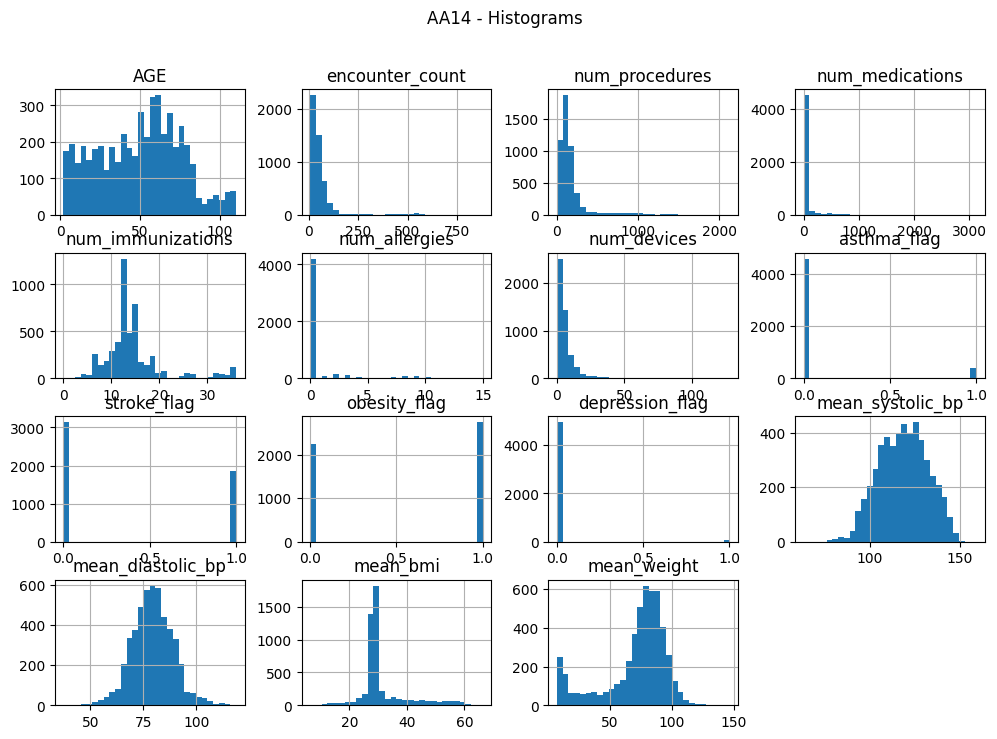


=== AA15: 基本統計量 ===
       GENDER          AGE   RACE    ETHNICITY  encounter_count  \
count    5000  5000.000000   5000         5000      5000.000000   
unique      2          NaN      6            2              NaN   
top         M          NaN  white  nonhispanic              NaN   
freq     2548          NaN   4306         4697              NaN   
mean      NaN    47.242800    NaN          NaN        66.672800   
std       NaN    27.046992    NaN          NaN        97.718268   
min       NaN     2.000000    NaN          NaN         8.000000   
25%       NaN    24.000000    NaN          NaN        26.000000   
50%       NaN    49.000000    NaN          NaN        39.000000   
75%       NaN    66.000000    NaN          NaN        66.000000   
max       NaN   110.000000    NaN          NaN       810.000000   

        num_procedures  num_medications  num_immunizations  num_allergies  \
count      5000.000000      5000.000000        5000.000000    5000.000000   
unique             N

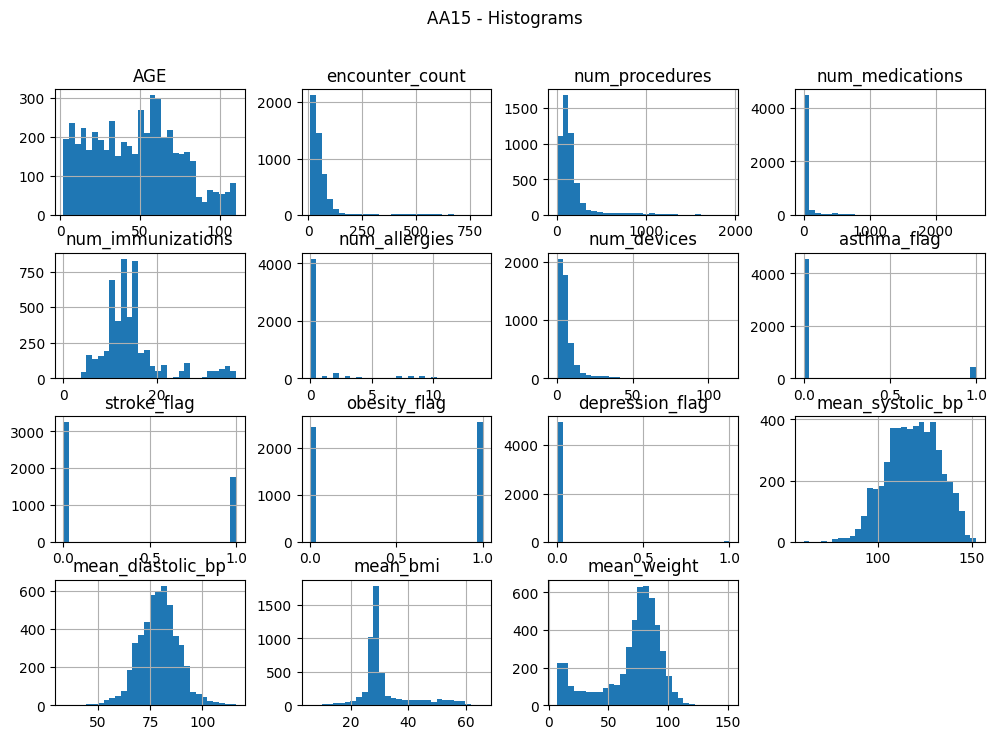


=== AA16: 基本統計量 ===
       GENDER          AGE   RACE    ETHNICITY  encounter_count  \
count    5000  5000.000000   5000         5000      5000.000000   
unique      2          NaN      6            2              NaN   
top         M          NaN  white  nonhispanic              NaN   
freq     2584          NaN   3850         4462              NaN   
mean      NaN    46.955600    NaN          NaN        61.750600   
std       NaN    23.914322    NaN          NaN        92.671126   
min       NaN     2.000000    NaN          NaN         7.000000   
25%       NaN    28.000000    NaN          NaN        26.000000   
50%       NaN    49.000000    NaN          NaN        38.000000   
75%       NaN    63.000000    NaN          NaN        60.000000   
max       NaN   110.000000    NaN          NaN       855.000000   

        num_procedures  num_medications  num_immunizations  num_allergies  \
count      5000.000000      5000.000000        5000.000000    5000.000000   
unique             N

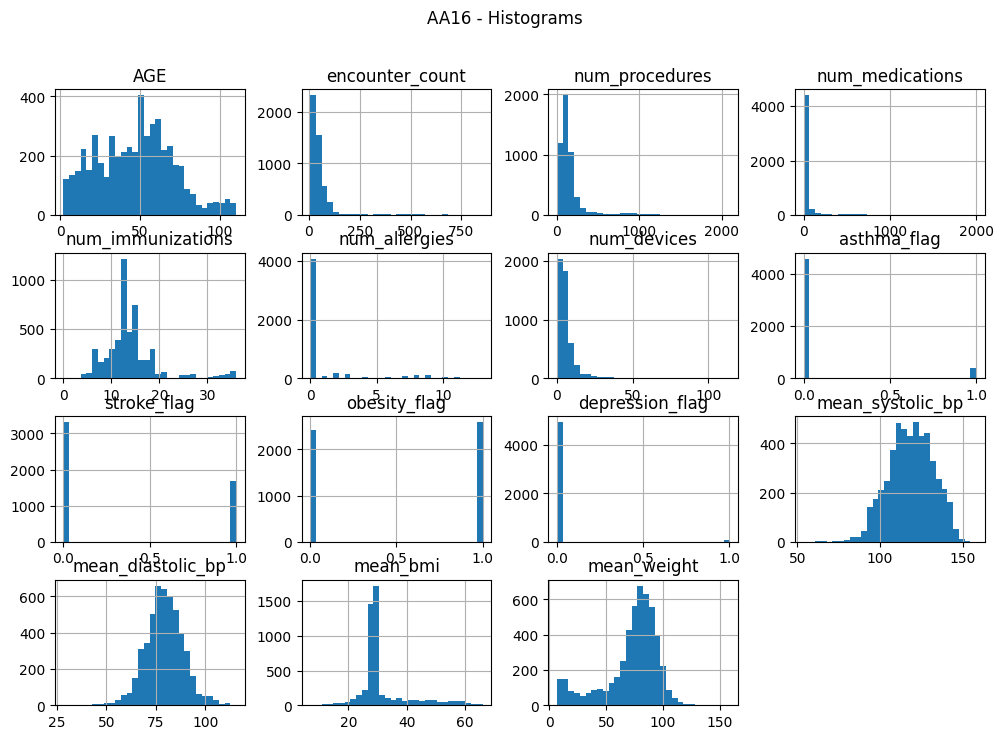


=== AA17: 基本統計量 ===
       GENDER          AGE   RACE    ETHNICITY  encounter_count  \
count    5000  5000.000000   5000         5000       5000.00000   
unique      2          NaN      6            2              NaN   
top         M          NaN  white  nonhispanic              NaN   
freq     2553          NaN   3333         4763              NaN   
mean      NaN    48.045800    NaN          NaN         70.35320   
std       NaN    29.333022    NaN          NaN        110.76594   
min       NaN     2.000000    NaN          NaN          7.00000   
25%       NaN    23.000000    NaN          NaN         25.00000   
50%       NaN    50.000000    NaN          NaN         38.00000   
75%       NaN    65.000000    NaN          NaN         63.00000   
max       NaN   110.000000    NaN          NaN        831.00000   

        num_procedures  num_medications  num_immunizations  num_allergies  \
count        5000.0000      5000.000000        5000.000000     5000.00000   
unique             N

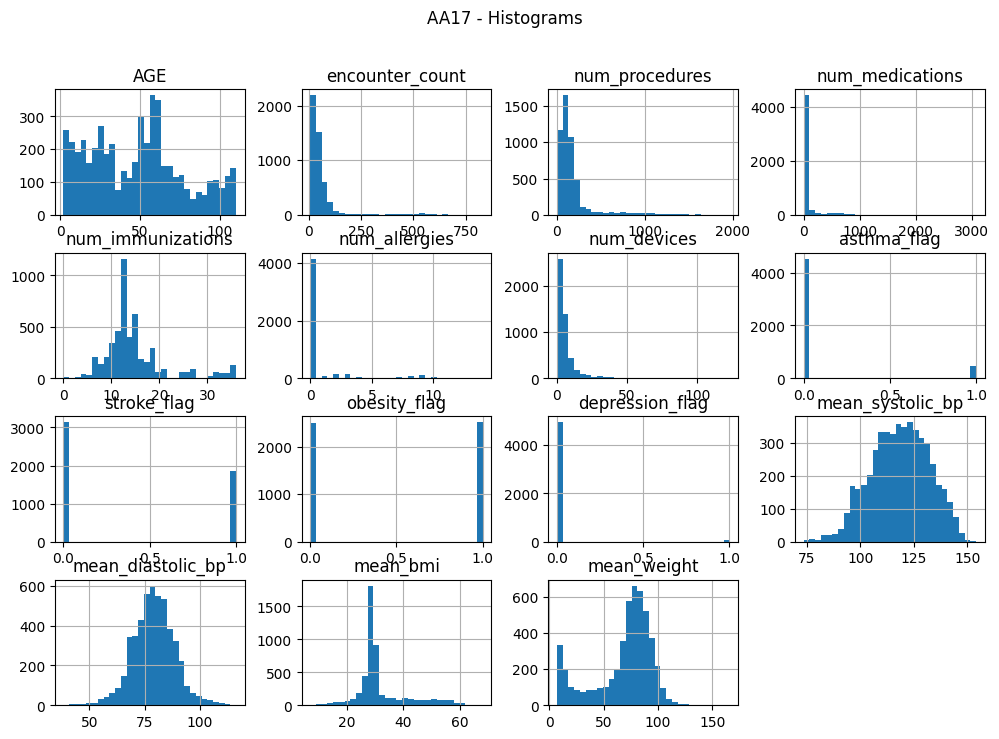


=== AA18: 基本統計量 ===
       GENDER          AGE   RACE    ETHNICITY  encounter_count  \
count    5000  5000.000000   5000         5000      5000.000000   
unique      2          NaN      6            2              NaN   
top         M          NaN  white  nonhispanic              NaN   
freq     2596          NaN   4135         3765              NaN   
mean      NaN    42.984000    NaN          NaN        57.323200   
std       NaN    25.178144    NaN          NaN        86.780803   
min       NaN     2.000000    NaN          NaN         6.000000   
25%       NaN    21.000000    NaN          NaN        24.000000   
50%       NaN    43.000000    NaN          NaN        34.000000   
75%       NaN    61.000000    NaN          NaN        56.000000   
max       NaN   110.000000    NaN          NaN       814.000000   

        num_procedures  num_medications  num_immunizations  num_allergies  \
count       5000.00000      5000.000000        5000.000000    5000.000000   
unique             N

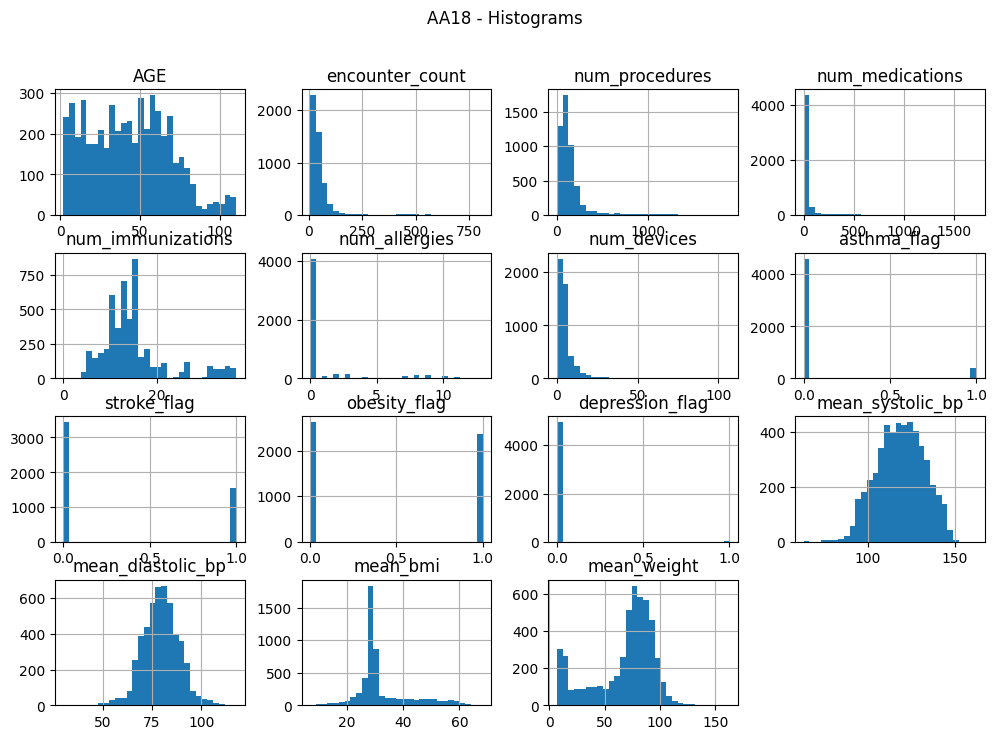


=== AA19: 基本統計量 ===
       GENDER          AGE   RACE    ETHNICITY  encounter_count  \
count    5000  5000.000000   5000         5000       5000.00000   
unique      2          NaN      6            2              NaN   
top         F          NaN  white  nonhispanic              NaN   
freq     2520          NaN   4762         4914              NaN   
mean      NaN    46.730600    NaN          NaN         59.63660   
std       NaN    25.749171    NaN          NaN         89.06173   
min       NaN     2.000000    NaN          NaN          7.00000   
25%       NaN    25.000000    NaN          NaN         25.00000   
50%       NaN    48.000000    NaN          NaN         36.00000   
75%       NaN    65.000000    NaN          NaN         57.00000   
max       NaN   110.000000    NaN          NaN        779.00000   

        num_procedures  num_medications  num_immunizations  num_allergies  \
count      5000.000000      5000.000000        5000.000000    5000.000000   
unique             N

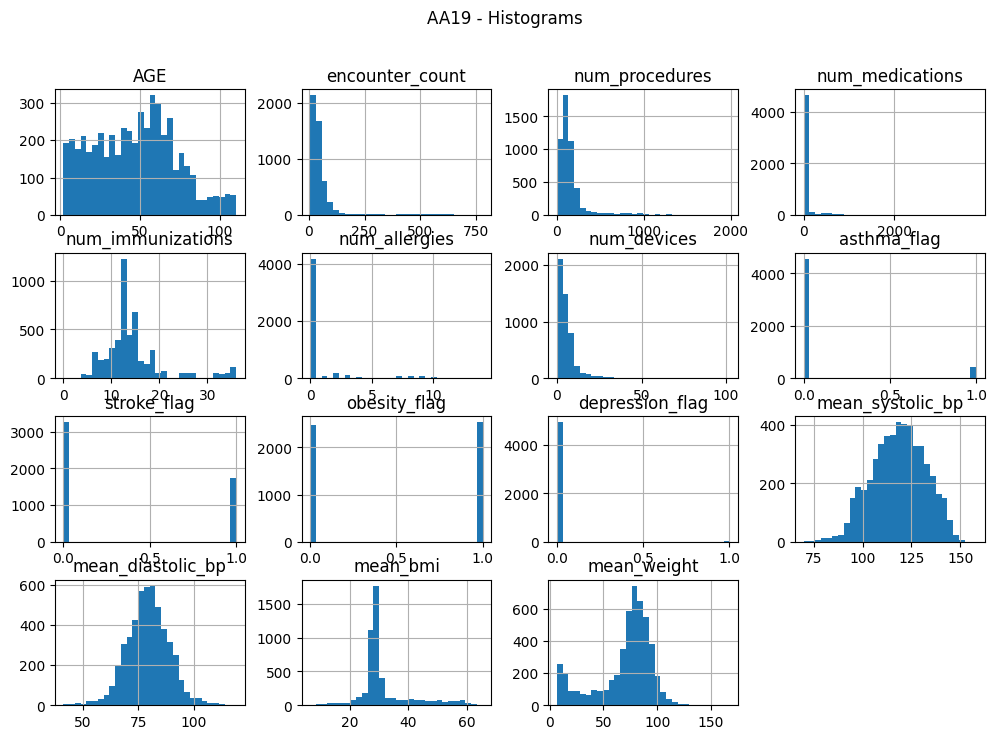


=== AA20: 基本統計量 ===
       GENDER          AGE   RACE    ETHNICITY  encounter_count  \
count    5000  5000.000000   5000         5000      5000.000000   
unique      2          NaN      6            2              NaN   
top         M          NaN  white  nonhispanic              NaN   
freq     2588          NaN   3776         4704              NaN   
mean      NaN    45.400800    NaN          NaN        62.853600   
std       NaN    25.054614    NaN          NaN        92.387532   
min       NaN     2.000000    NaN          NaN         6.000000   
25%       NaN    25.000000    NaN          NaN        25.000000   
50%       NaN    45.000000    NaN          NaN        38.000000   
75%       NaN    63.000000    NaN          NaN        62.250000   
max       NaN   110.000000    NaN          NaN       852.000000   

        num_procedures  num_medications  num_immunizations  num_allergies  \
count      5000.000000      5000.000000        5000.000000    5000.000000   
unique             N

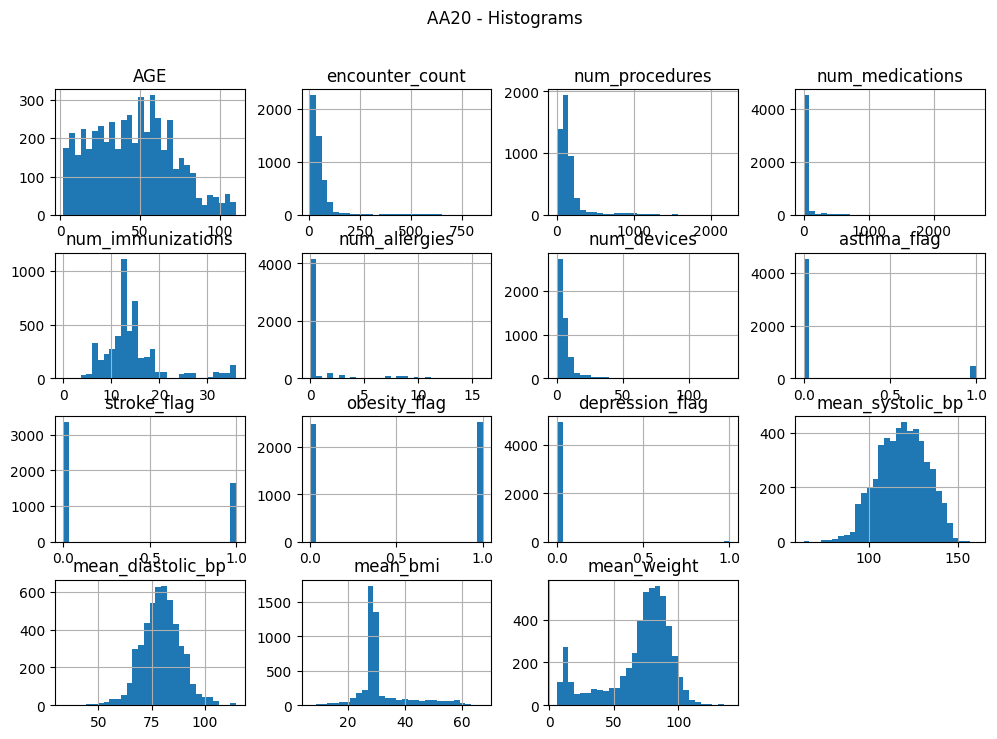


=== AA22: 基本統計量 ===
       GENDER          AGE   RACE    ETHNICITY  encounter_count  \
count    5000  5000.000000   5000         5000      5000.000000   
unique      2          NaN      6            2              NaN   
top         M          NaN  white  nonhispanic              NaN   
freq     2537          NaN   4783         4867              NaN   
mean      NaN    49.477800    NaN          NaN        67.355800   
std       NaN    26.242653    NaN          NaN        98.003372   
min       NaN     2.000000    NaN          NaN         6.000000   
25%       NaN    27.000000    NaN          NaN        27.000000   
50%       NaN    52.000000    NaN          NaN        40.000000   
75%       NaN    69.000000    NaN          NaN        66.000000   
max       NaN   110.000000    NaN          NaN       828.000000   

        num_procedures  num_medications  num_immunizations  num_allergies  \
count       5000.00000      5000.000000        5000.000000    5000.000000   
unique             N

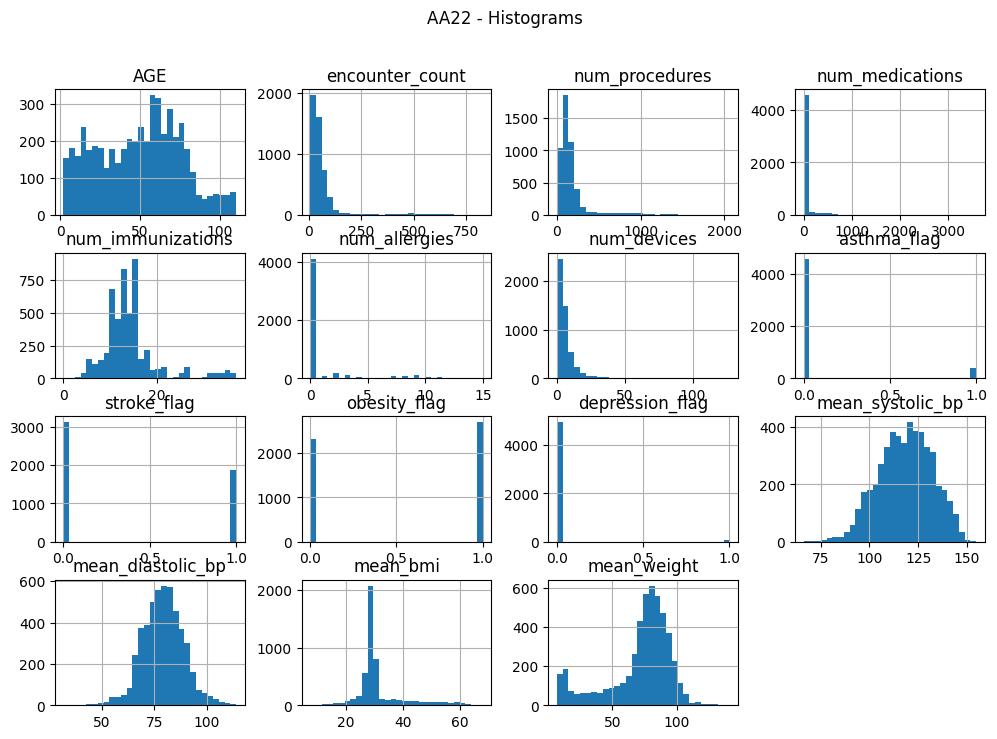


=== AA23: 基本統計量 ===
       GENDER          AGE   RACE    ETHNICITY  encounter_count  \
count    5000  5000.000000   5000         5000      5000.000000   
unique      2          NaN      6            2              NaN   
top         M          NaN  white  nonhispanic              NaN   
freq     2661          NaN   4473         4893              NaN   
mean      NaN    50.385400    NaN          NaN        65.919800   
std       NaN    25.195853    NaN          NaN        98.852454   
min       NaN     2.000000    NaN          NaN         9.000000   
25%       NaN    30.000000    NaN          NaN        27.000000   
50%       NaN    53.000000    NaN          NaN        39.000000   
75%       NaN    68.000000    NaN          NaN        62.000000   
max       NaN   110.000000    NaN          NaN       862.000000   

        num_procedures  num_medications  num_immunizations  num_allergies  \
count      5000.000000      5000.000000        5000.000000    5000.000000   
unique             N

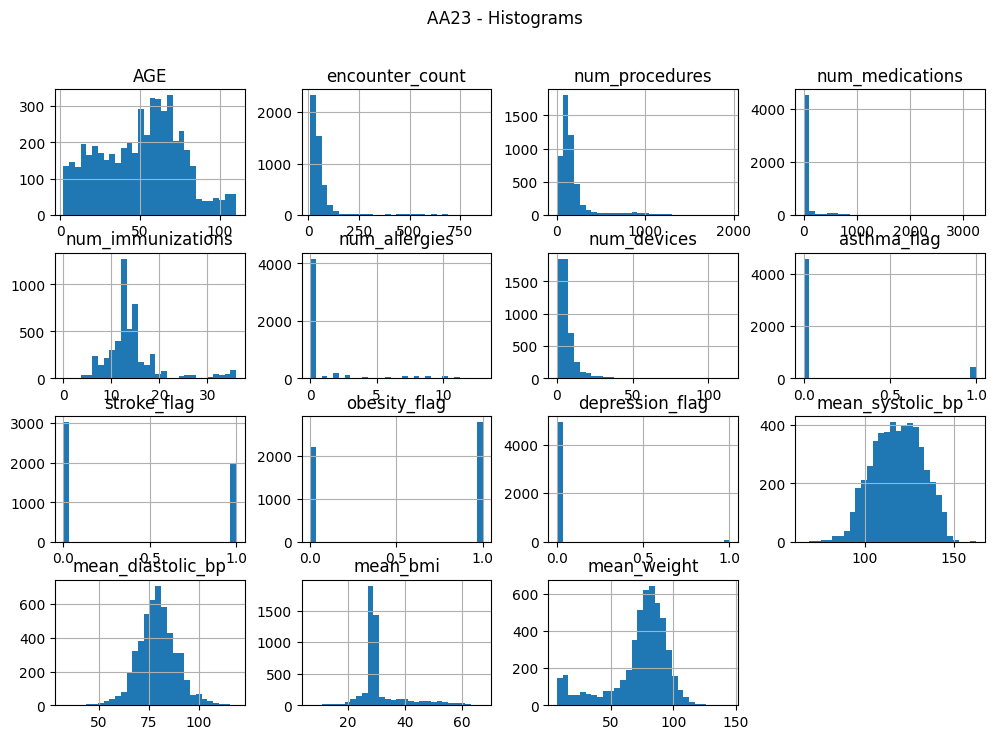


=== AA24: 基本統計量 ===
       GENDER          AGE   RACE    ETHNICITY  encounter_count  \
count    5000  5000.000000   5000         5000      5000.000000   
unique      2          NaN      6            2              NaN   
top         M          NaN  white  nonhispanic              NaN   
freq     2592          NaN   4505         4674              NaN   
mean      NaN    45.531000    NaN          NaN        61.904600   
std       NaN    26.094636    NaN          NaN        95.978182   
min       NaN     2.000000    NaN          NaN         6.000000   
25%       NaN    23.000000    NaN          NaN        25.000000   
50%       NaN    45.000000    NaN          NaN        37.000000   
75%       NaN    64.000000    NaN          NaN        59.000000   
max       NaN   110.000000    NaN          NaN       820.000000   

        num_procedures  num_medications  num_immunizations  num_allergies  \
count      5000.000000      5000.000000        5000.000000    5000.000000   
unique             N

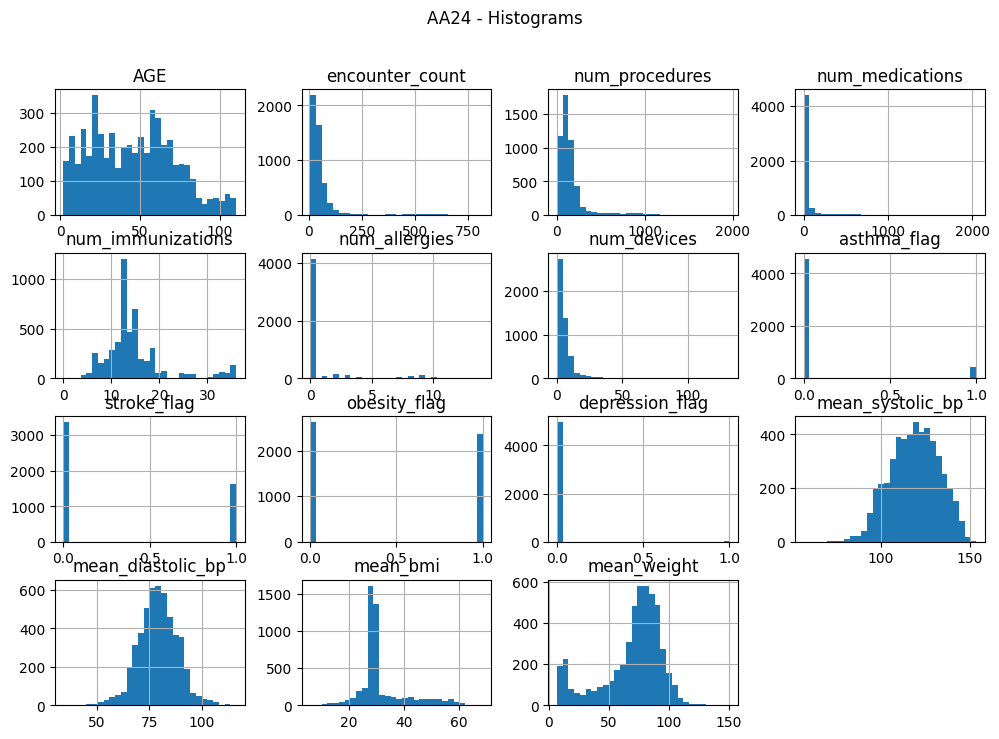

In [5]:
# %% 1. 基本統計量の比較
for name, df in zip(dataset_names, datasets):
    print(f"\n=== {name}: 基本統計量 ===")
    print(df.describe(include="all"))

    # 数値分布のヒストグラム
    df.hist(figsize=(12, 8), bins=30)
    plt.suptitle(f"{name} - Histograms")
    plt.show()

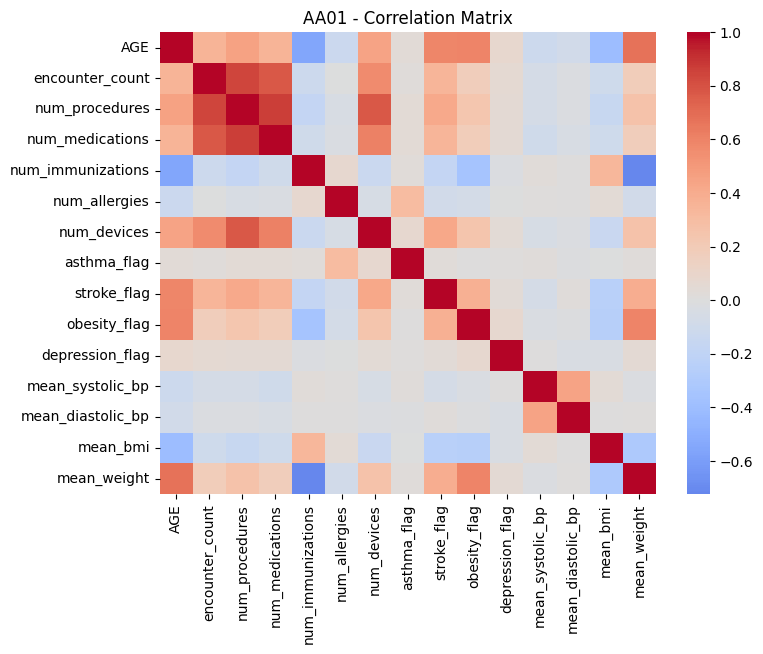

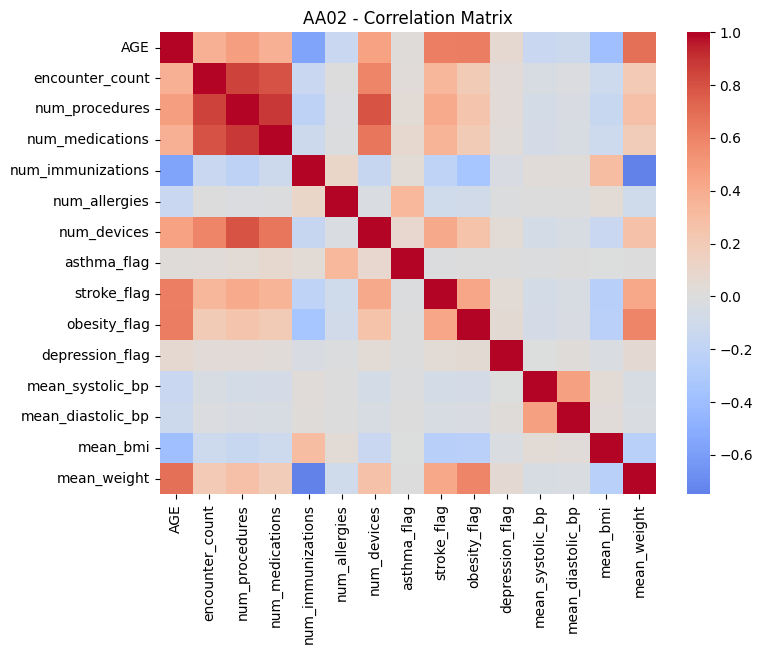

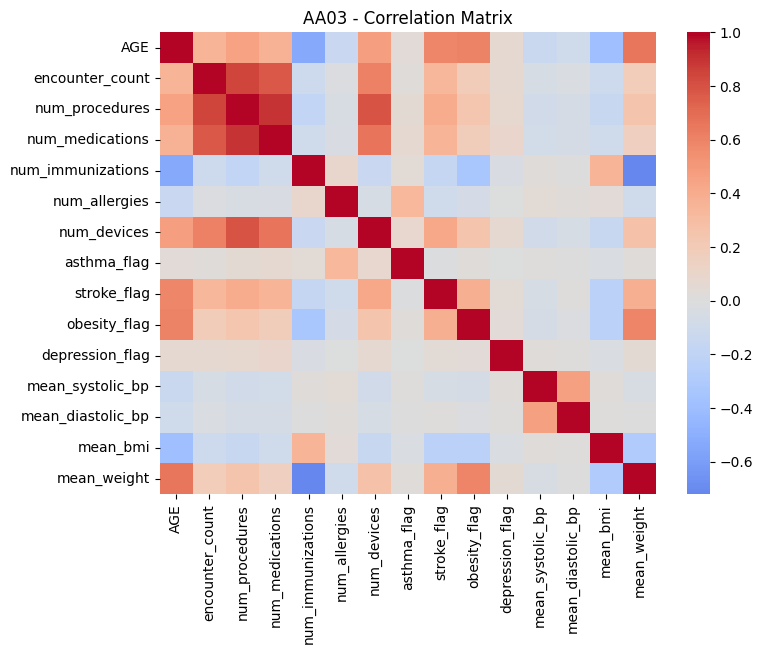

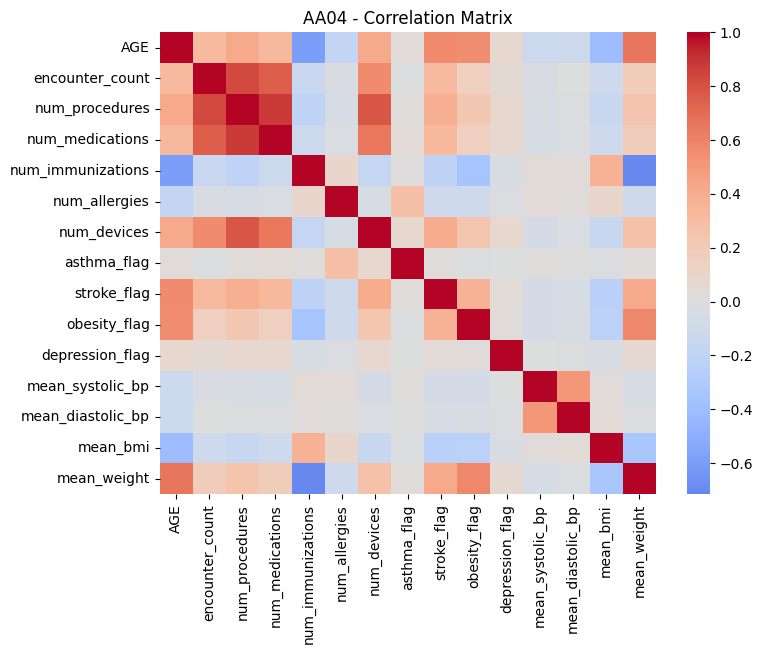

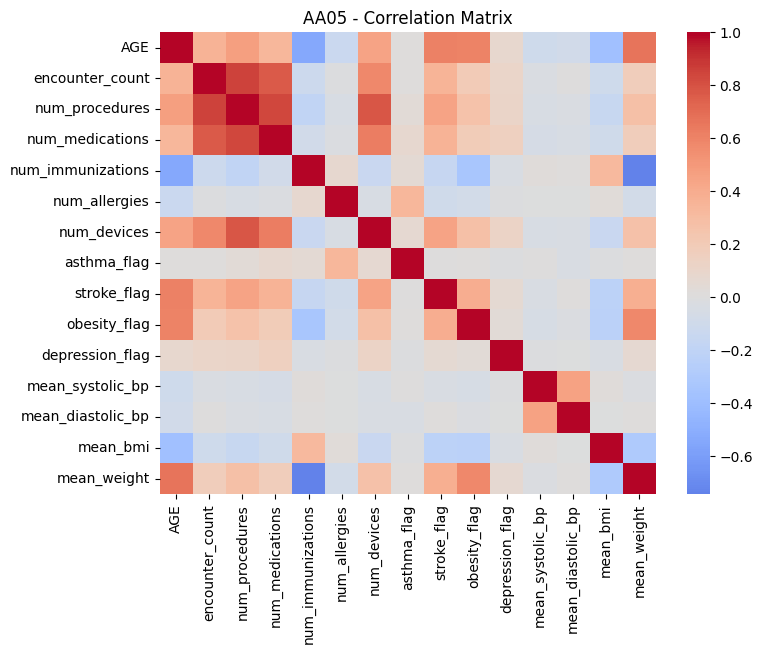

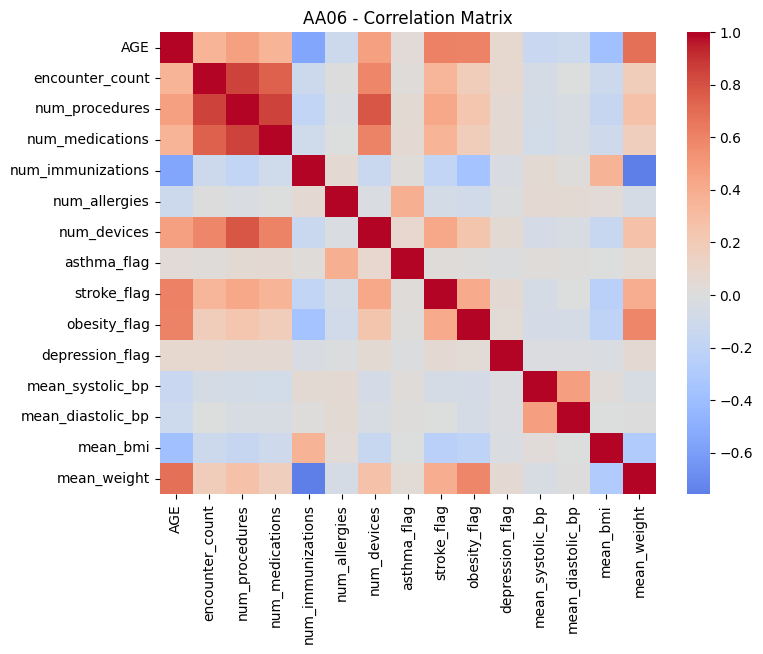

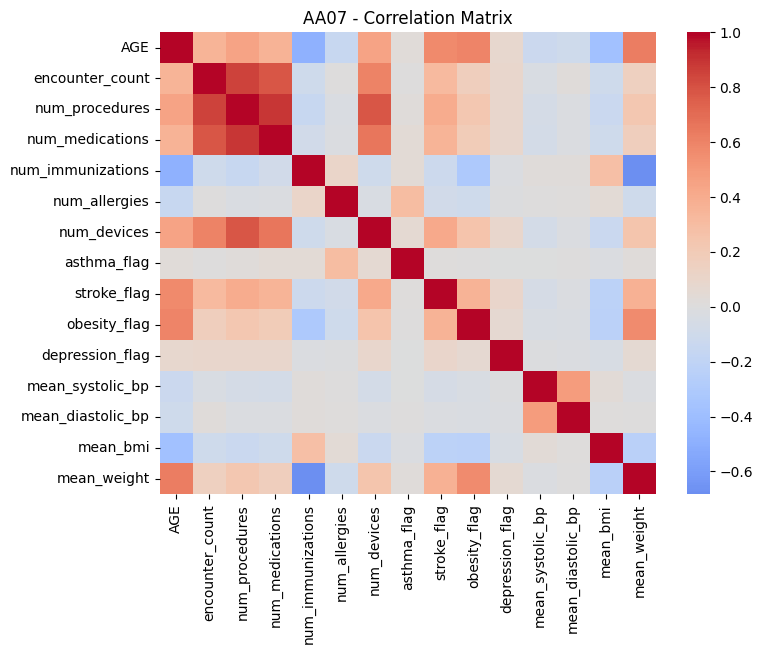

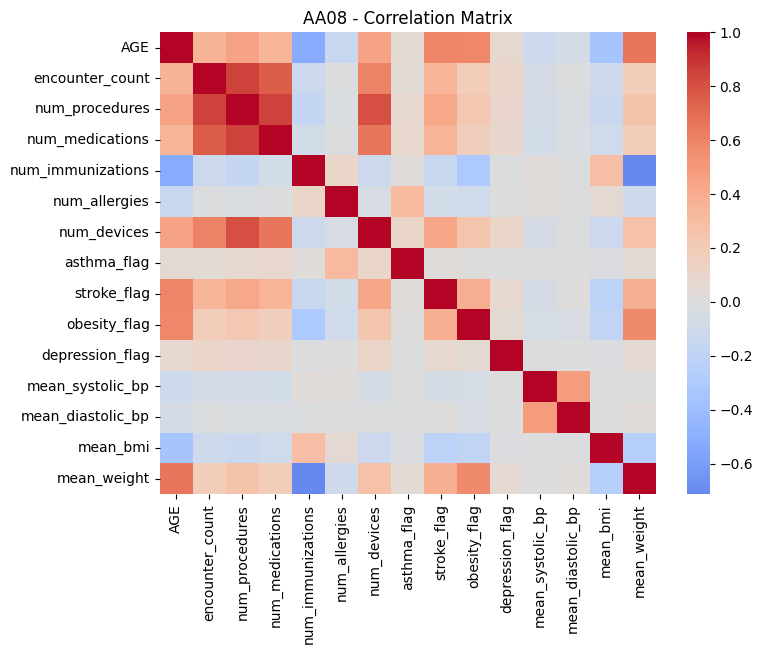

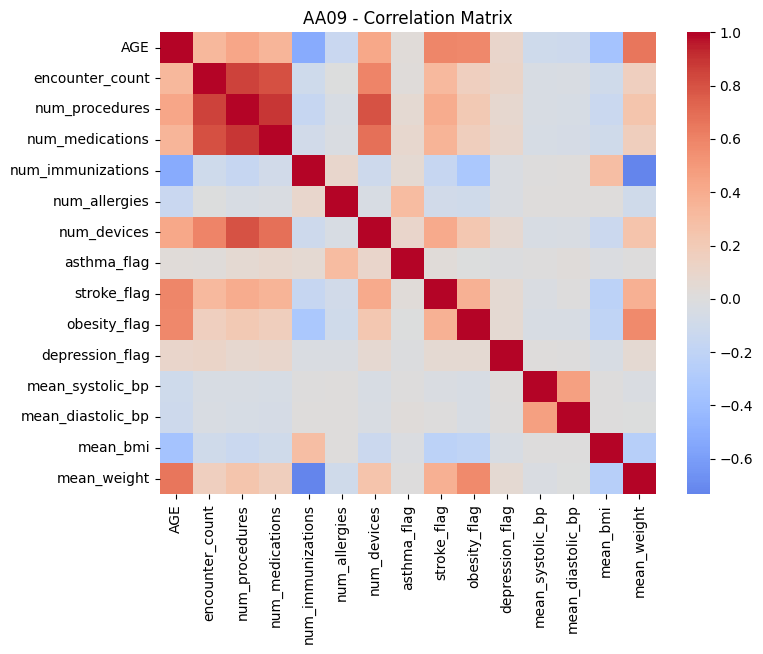

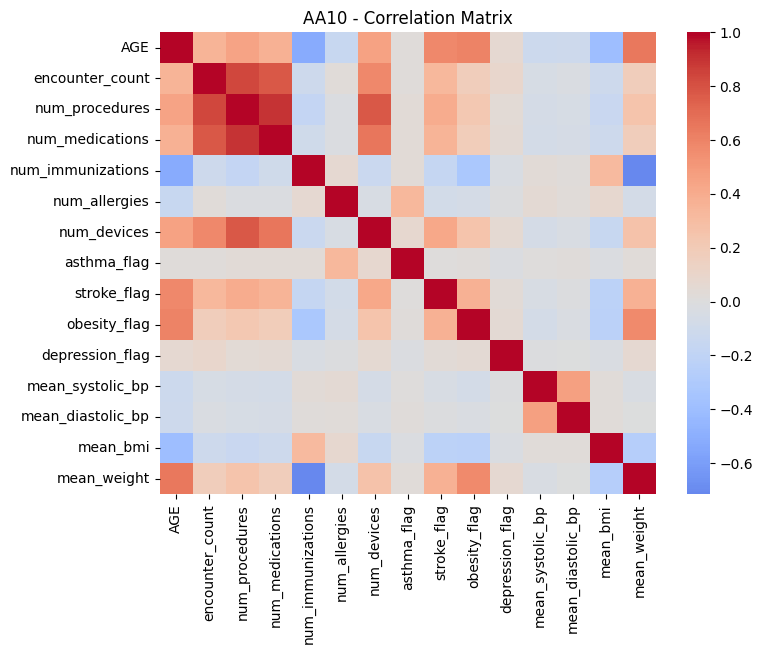

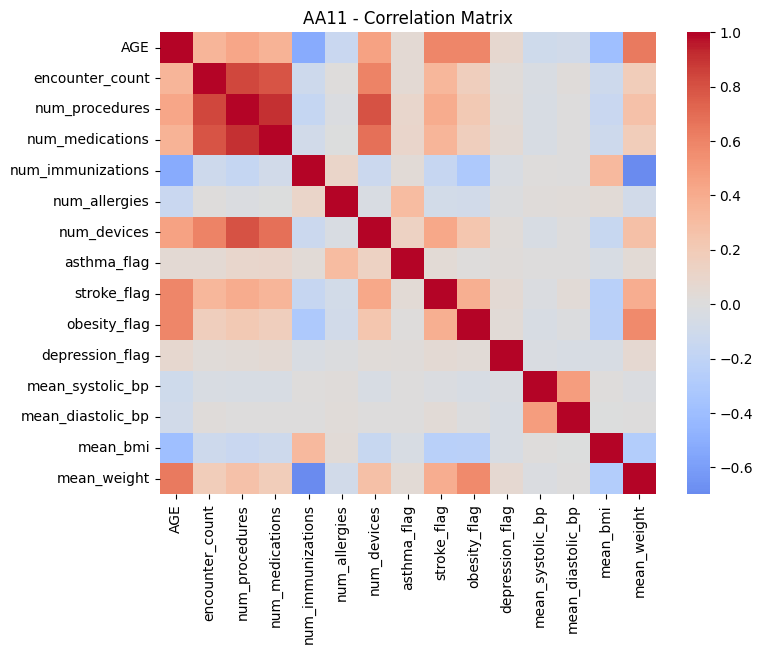

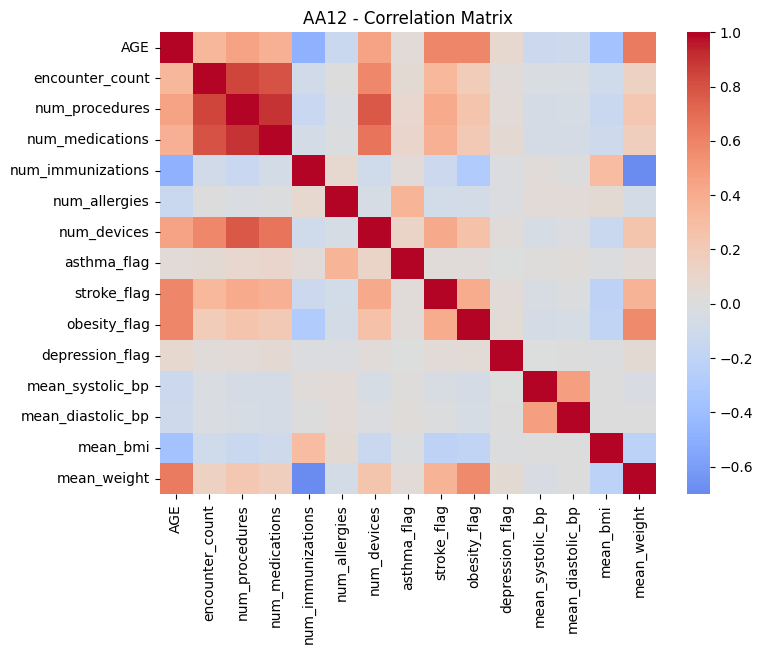

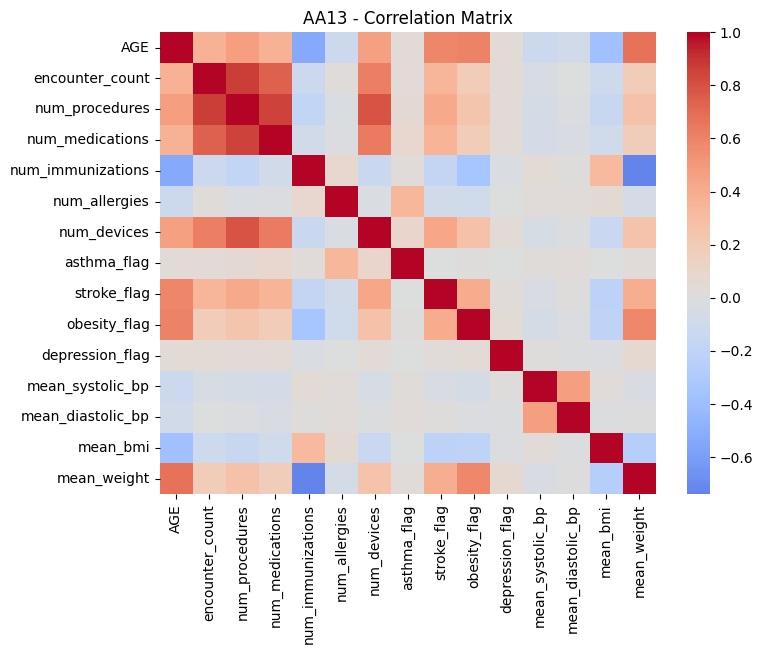

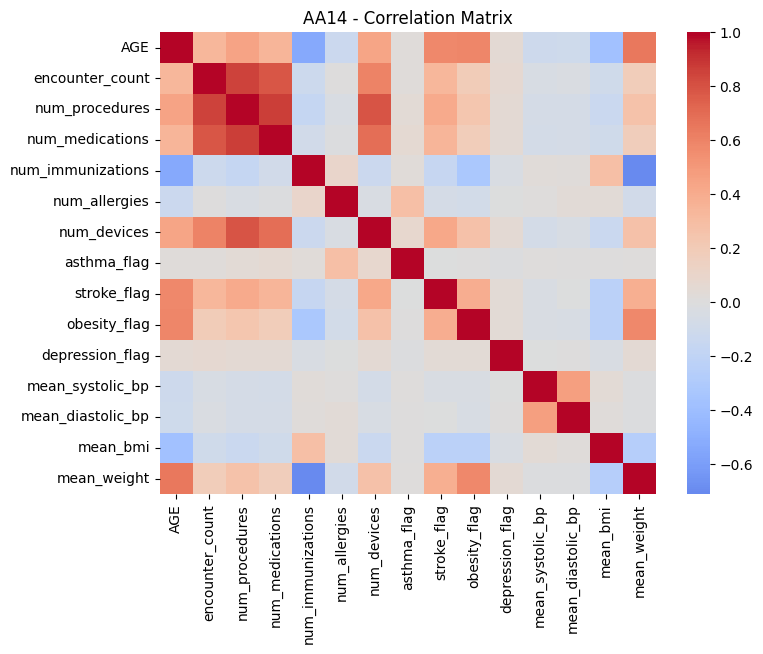

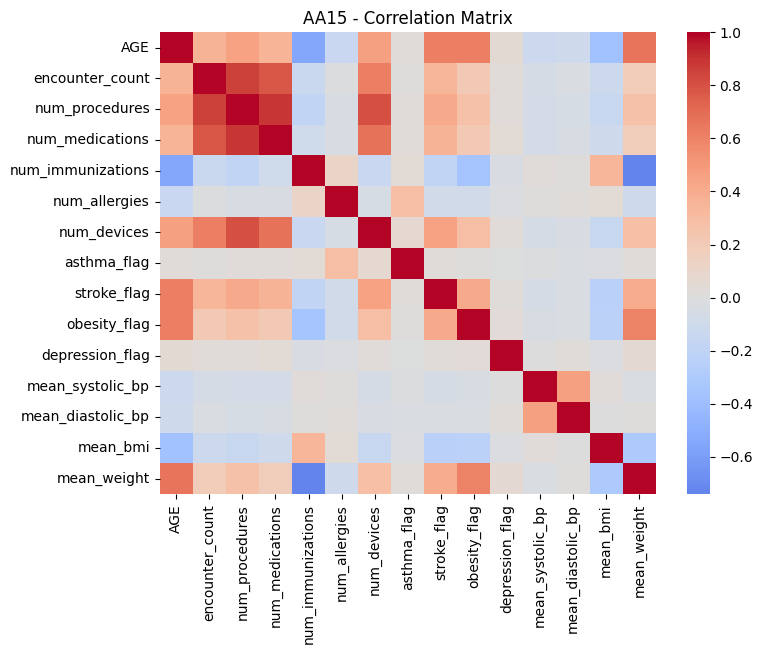

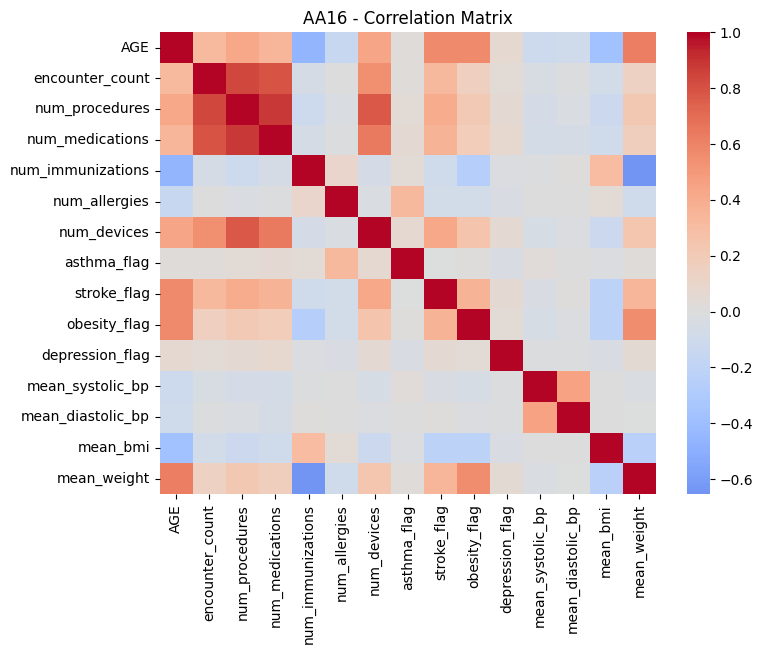

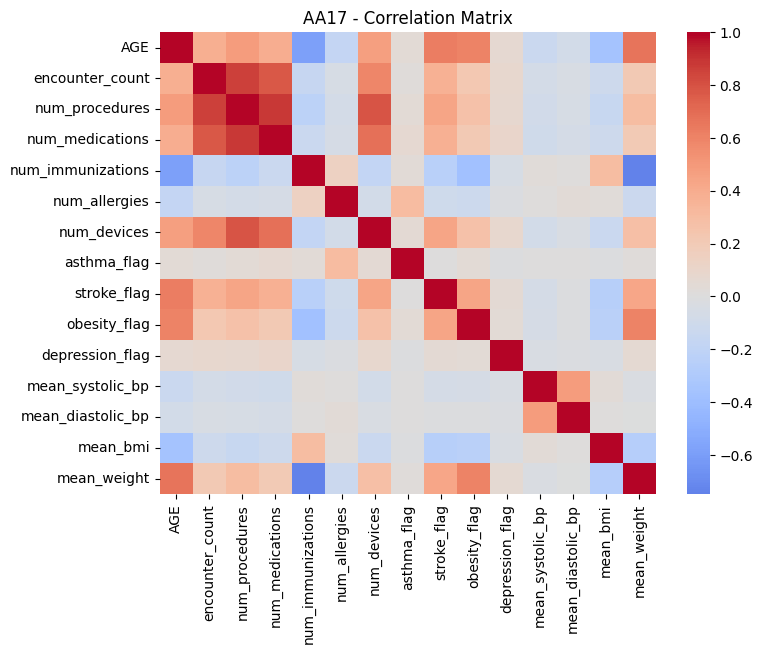

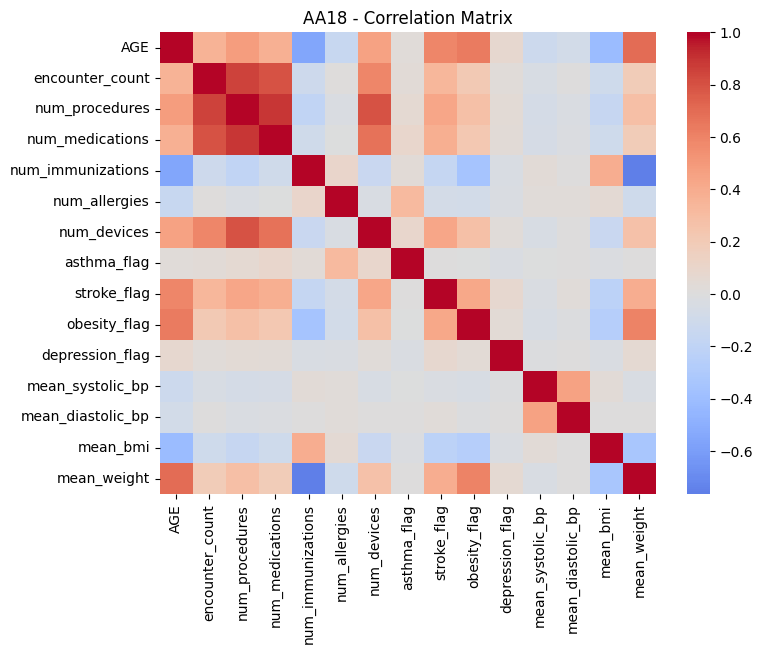

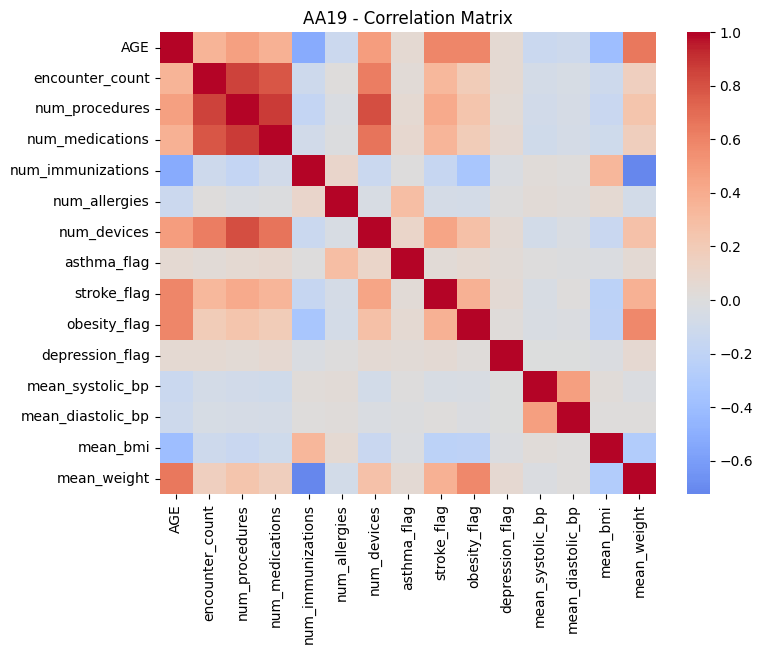

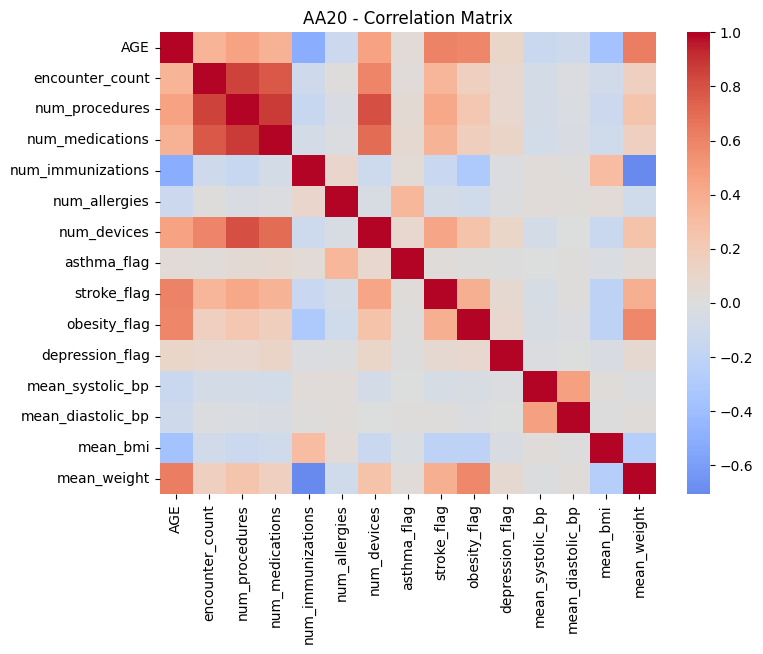

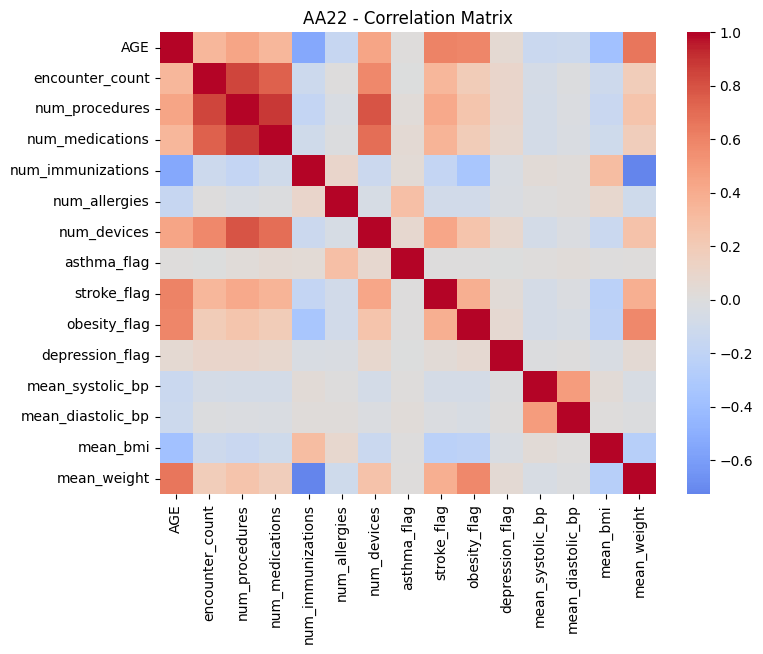

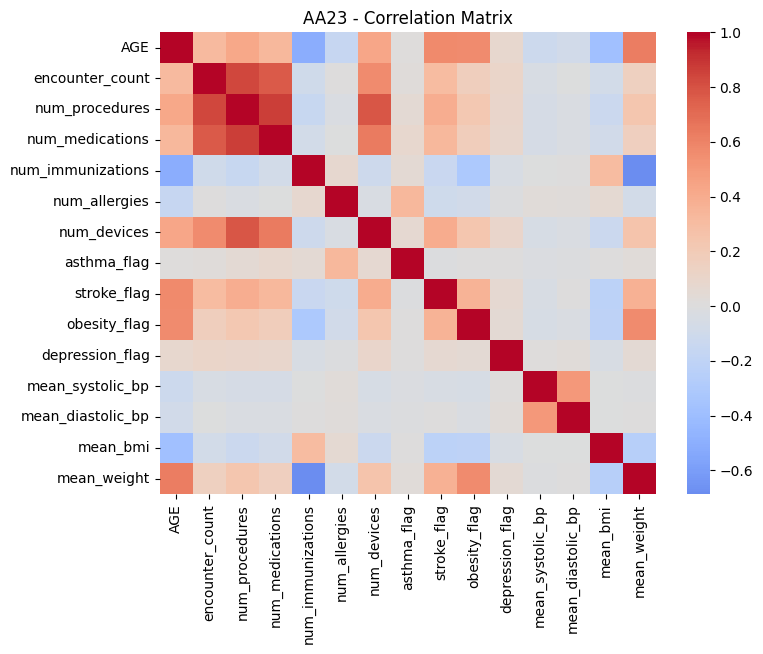

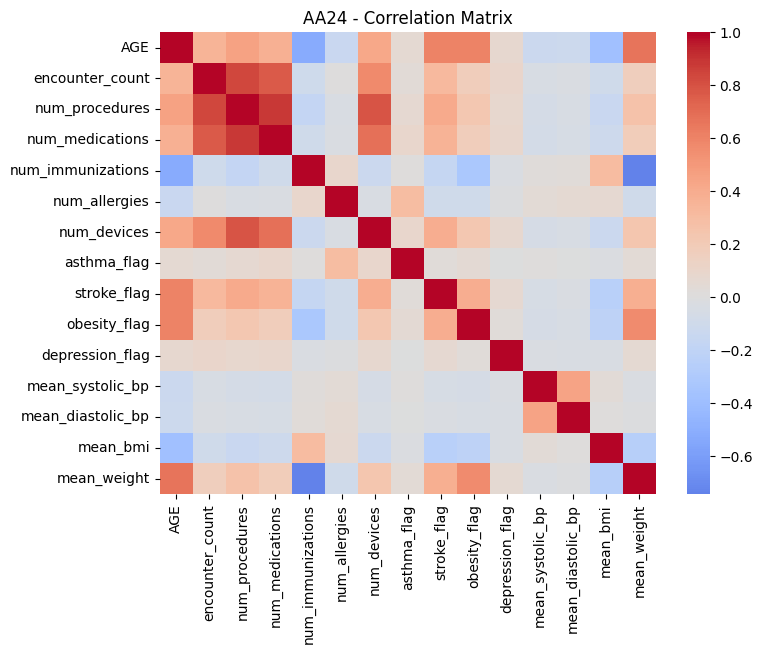

In [6]:
# %% 2. 相関構造の比較
for name, df in zip(dataset_names, datasets):
    corr = df.corr(numeric_only=True)
    plt.figure(figsize=(8,6))
    sns.heatmap(corr, annot=False, cmap="coolwarm", center=0)
    plt.title(f"{name} - Correlation Matrix")
    plt.show()

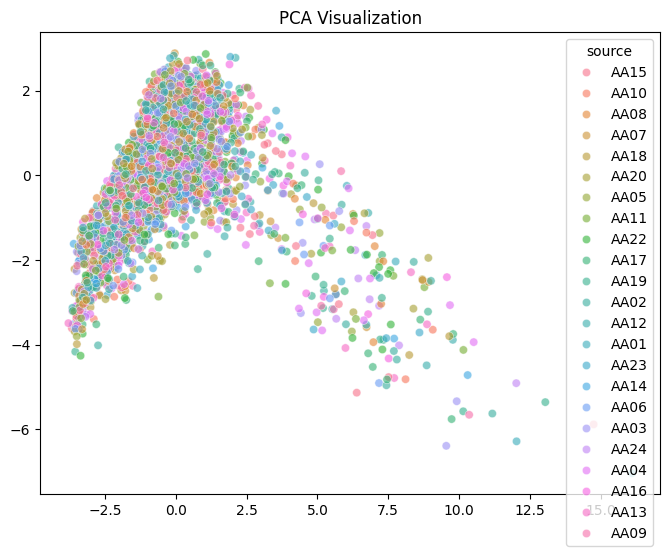

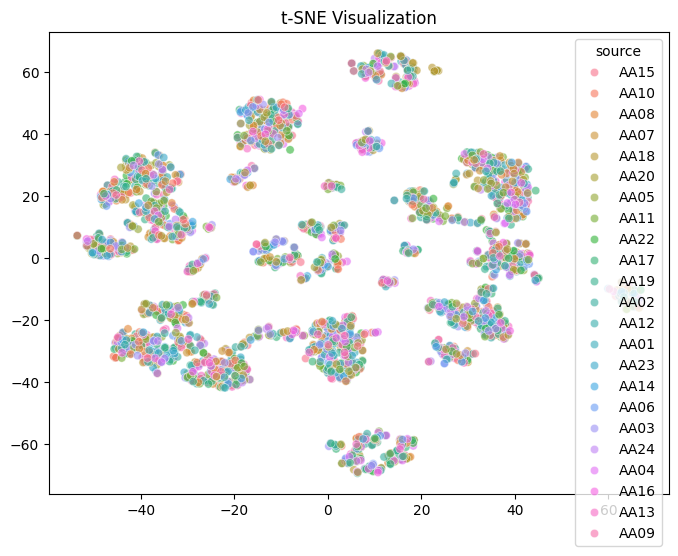

In [7]:
# %% 3. 次元削減による可視化 (PCA, t-SNE)
combined = []
for i, df in enumerate(datasets):
    temp = df.copy()
    temp["source"] = dataset_names[i]
    combined.append(temp)
combined_df = pd.concat(combined, ignore_index=True)

feature_df = combined_df.drop(columns=["source"])
encoded_df = pd.get_dummies(feature_df, drop_first=False)
if encoded_df.empty:
    raise ValueError("特徴量が存在しません。入力データを確認してください。")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(encoded_df)
y = combined_df["source"]

rng = np.random.default_rng(42)
viz_sample_size = min(3000, X_scaled.shape[0])
if viz_sample_size < X_scaled.shape[0]:
    sample_idx = rng.choice(X_scaled.shape[0], viz_sample_size, replace=False)
else:
    sample_idx = np.arange(X_scaled.shape[0])

X_viz = X_scaled[sample_idx]
y_viz = y.iloc[sample_idx].reset_index(drop=True)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_viz)
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=y_viz, alpha=0.6)
plt.title("PCA Visualization")
plt.show()

# t-SNE
perplexity = min(30, max(5, viz_sample_size - 1))
tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity)
X_tsne = tsne.fit_transform(X_viz)
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1], hue=y_viz, alpha=0.6)
plt.title("t-SNE Visualization")
plt.show()


In [8]:
# %% 4. 判別モデルによる識別精度
clf = RandomForestClassifier(n_estimators=200, random_state=42)
scores = cross_val_score(clf, X_scaled, y, cv=5, scoring="accuracy")
print("\n=== 判別モデル精度 ===")
print(f"平均精度: {scores.mean():.3f} (± {scores.std():.3f})")
print("※ 精度が低ければ区別できない → データの特徴は類似")



=== 判別モデル精度 ===
平均精度: 0.072 (± 0.002)
※ 精度が低ければ区別できない → データの特徴は類似


In [9]:
# %% 5. 統計的検定
print("=== 分布の統計的検定 ===")
numeric_cols = combined_df.select_dtypes(include=[np.number]).columns

if len(numeric_cols) == 0:
    print("数値列が見つかりませんでした。")
else:
    for col in numeric_cols:
        data_groups = [df[col].dropna() for df in datasets]
        for i in range(len(data_groups)):
            for j in range(i+1, len(data_groups)):
                if data_groups[i].empty or data_groups[j].empty:
                    continue
                stat, pval = ks_2samp(data_groups[i], data_groups[j])
                print(f"{col}: {dataset_names[i]} vs {dataset_names[j]} → p={pval:.4f}")

categorical_cols = combined_df.select_dtypes(include=["object", "category"]).columns
for col in categorical_cols:
    contingency = pd.crosstab(combined_df[col], combined_df["source"])
    if contingency.empty:
        continue
    chi2, pval, _, _ = chi2_contingency(contingency)
    print(f"{col}: カイ二乗検定 p={pval:.4f}")

# （高度な手法）MMDによる分布差の測定 (RBFカーネル)
def mmd(X1, X2, gamma=1.0):
    XX = np.exp(-gamma * np.square(np.linalg.norm(X1[:,None]-X1[None,:], axis=2))).mean()
    YY = np.exp(-gamma * np.square(np.linalg.norm(X2[:,None]-X2[None,:], axis=2))).mean()
    XY = np.exp(-gamma * np.square(np.linalg.norm(X1[:,None]-X2[None,:], axis=2))).mean()
    return XX + YY - 2*XY

def sample_subset(arr, size, rng):
    if len(arr) > size:
        idx = rng.choice(len(arr), size, replace=False)
        return arr[idx]
    return arr

rng = np.random.default_rng(42)
mmd_sample_size = 500

print("=== MMDによる分布距離 ===")
for i in range(len(datasets)):
    for j in range(i+1, len(datasets)):
        mask_i = (y == dataset_names[i]).to_numpy()
        mask_j = (y == dataset_names[j]).to_numpy()
        X_i = sample_subset(X_scaled[mask_i], mmd_sample_size, rng)
        X_j = sample_subset(X_scaled[mask_j], mmd_sample_size, rng)
        if len(X_i) == 0 or len(X_j) == 0:
            continue
        val = mmd(X_i, X_j)
        print(f"{dataset_names[i]} vs {dataset_names[j]}: MMD={val:.4f}")


=== 分布の統計的検定 ===
AGE: AA01 vs AA02 → p=0.0000
AGE: AA01 vs AA03 → p=0.0031
AGE: AA01 vs AA04 → p=0.0000
AGE: AA01 vs AA05 → p=0.0265
AGE: AA01 vs AA06 → p=0.0000
AGE: AA01 vs AA07 → p=0.0000
AGE: AA01 vs AA08 → p=0.0012
AGE: AA01 vs AA09 → p=0.0010
AGE: AA01 vs AA10 → p=0.0001
AGE: AA01 vs AA11 → p=0.0002
AGE: AA01 vs AA12 → p=0.0000
AGE: AA01 vs AA13 → p=0.0000
AGE: AA01 vs AA14 → p=0.0000
AGE: AA01 vs AA15 → p=0.0001
AGE: AA01 vs AA16 → p=0.0000
AGE: AA01 vs AA17 → p=0.0000
AGE: AA01 vs AA18 → p=0.0000
AGE: AA01 vs AA19 → p=0.0316
AGE: AA01 vs AA20 → p=0.0001
AGE: AA01 vs AA22 → p=0.0000
AGE: AA01 vs AA23 → p=0.0000
AGE: AA01 vs AA24 → p=0.0000
AGE: AA02 vs AA03 → p=0.0000
AGE: AA02 vs AA04 → p=0.0000
AGE: AA02 vs AA05 → p=0.0000
AGE: AA02 vs AA06 → p=0.0000
AGE: AA02 vs AA07 → p=0.0000
AGE: AA02 vs AA08 → p=0.0000
AGE: AA02 vs AA09 → p=0.0000
AGE: AA02 vs AA10 → p=0.0551
AGE: AA02 vs AA11 → p=0.0000
AGE: AA02 vs AA12 → p=0.0000
AGE: AA02 vs AA13 → p=0.0000
AGE: AA02 vs AA14 → p=0.00

c:\Users\hinata\anaconda3\envs\pwscup2025\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)


num_allergies: AA07 vs AA09 → p=1.0000
num_allergies: AA07 vs AA10 → p=1.0000
num_allergies: AA07 vs AA11 → p=1.0000
num_allergies: AA07 vs AA12 → p=0.9229
num_allergies: AA07 vs AA13 → p=0.9972
num_allergies: AA07 vs AA14 → p=0.7113
num_allergies: AA07 vs AA15 → p=0.9972
num_allergies: AA07 vs AA16 → p=0.8897
num_allergies: AA07 vs AA17 → p=1.0000
num_allergies: AA07 vs AA18 → p=0.5280
num_allergies: AA07 vs AA19 → p=0.9014
num_allergies: AA07 vs AA20 → p=0.9997
num_allergies: AA07 vs AA22 → p=0.9998
num_allergies: AA07 vs AA23 → p=1.0000
num_allergies: AA07 vs AA24 → p=0.9840
num_allergies: AA08 vs AA09 → p=0.9014
num_allergies: AA08 vs AA10 → p=0.9997
num_allergies: AA08 vs AA11 → p=0.9874
num_allergies: AA08 vs AA12 → p=0.3791
num_allergies: AA08 vs AA13 → p=0.4807
num_allergies: AA08 vs AA14 → p=0.9960
num_allergies: AA08 vs AA15 → p=1.0000
num_allergies: AA08 vs AA16 → p=0.2492
num_allergies: AA08 vs AA17 → p=0.9981
num_allergies: AA08 vs AA18 → p=0.1701
num_allergies: AA08 vs AA